# 14 — LaMa Restoration

## Purpose

This notebook applies LaMa inpainting to the same restoration-case families used by the OpenCV Telea baseline so that downstream metrics can compare models on a standardized evidence structure.

The notebook processes:

- canonical controlled-damage cases;
- damage-size sensitivity cases;
- mask-robustness cases when available;
- methodologically eligible synthetic-degradation cases when available.

## Restoration method

The implementation uses IOPaint with `model=lama`. LaMa is treated as a learned inpainting model, not as a historically verified conservation method.

## Case identifiers

Each upstream dataset is normalized into a shared LaMa restoration-input schema. Source case identifiers are made globally unique before model execution:

```text
<dataset_name>__<original_case_id>
```

The helper then creates LaMa restoration identifiers:

```text
lama__<dataset_name>__<source_case_id>
```

This preserves the original case ID while avoiding collisions across canonical, damage-size, mask-robustness, and synthetic-degradation branches.

## Output policy

Permanent CSV output is intentionally limited:

- `data/processed/metadata/metadata_restored_lama.csv` — main downstream restoration manifest;
- `outputs/14_lama_restoration/lama_restoration_audit.csv` — compact validation/audit table;
- `outputs/figures/lama/lama_figure_manifest.csv` — figure index if representative figures are generated.

Image outputs are not capped. If a case is eligible, the notebook should restore it unless generation fails and the failure is logged.


In [1]:
from pathlib import Path


def find_project_root(start_path: Path | None = None) -> Path:
    """Locate the repository root from the current working directory."""
    current_path = Path.cwd() if start_path is None else Path(start_path)
    current_path = current_path.resolve()

    for candidate_path in (current_path, *current_path.parents):
        if (
            (candidate_path / "src").is_dir()
            and (candidate_path / "notebooks").is_dir()
            and (
                (candidate_path / ".git").exists()
                or (candidate_path / "README.md").exists()
            )
        ):
            return candidate_path

    raise FileNotFoundError(
        "Could not locate the project root. Run this notebook from within the repository."
    )


PROJECT_ROOT = find_project_root()

print("Project root:", PROJECT_ROOT)


Project root: D:\Masters\FH\Thesis\painting-restoration-eval


In [2]:
import json
import platform
import shutil
import subprocess
import sys
from datetime import datetime, timezone
from textwrap import dedent

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from PIL import Image

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


from restoration_eval.restoration_lama import (
    DEFAULT_DEVICE,
    DEFAULT_MASK_THRESHOLD,
    DEFAULT_TARGET_SIZE,
    IOPAINT_MODEL_NAME,
    MODEL_NAME,
    RESTORATION_GENERATOR_NAME,
    RESTORATION_GENERATOR_VERSION,
    audit_lama_restoration_inventory,
    build_lama_restoration_audit_table,
    create_lama_restoration_dataset,
    get_lama_runtime_environment,
    normalize_lama_restoration_input_manifest,
    summarize_lama_restoration,
    validate_lama_restoration_behavior,
    validate_restoration_input_manifest,
    validate_restored_images,
)


required_lama_api = {
    "normalize_lama_restoration_input_manifest": normalize_lama_restoration_input_manifest,
    "validate_restoration_input_manifest": validate_restoration_input_manifest,
    "create_lama_restoration_dataset": create_lama_restoration_dataset,
    "validate_restored_images": validate_restored_images,
    "validate_lama_restoration_behavior": validate_lama_restoration_behavior,
    "audit_lama_restoration_inventory": audit_lama_restoration_inventory,
    "summarize_lama_restoration": summarize_lama_restoration,
    "build_lama_restoration_audit_table": build_lama_restoration_audit_table,
    "get_lama_runtime_environment": get_lama_runtime_environment,
}

invalid_api_names = [
    api_name
    for api_name, api_object in required_lama_api.items()
    if not callable(api_object)
]

if invalid_api_names:
    raise RuntimeError(f"Required LaMa helper APIs are not callable: {invalid_api_names}")

print("LaMa helper:", RESTORATION_GENERATOR_NAME, RESTORATION_GENERATOR_VERSION)


LaMa helper: restoration_eval.restoration_lama 2.0.0


In [3]:
def project_relative_path(path_value: str | Path) -> str:
    """Return a repository-relative POSIX path when possible."""
    path = Path(path_value)

    if not path.is_absolute():
        path = PROJECT_ROOT / path

    path = path.resolve()

    try:
        return path.relative_to(PROJECT_ROOT).as_posix()
    except ValueError:
        return path.as_posix()


def resolve_project_path(path_value: str | Path) -> Path:
    """Resolve an absolute or repository-relative path."""
    path = Path(str(path_value))

    if path.is_absolute():
        return path.resolve()

    return (PROJECT_ROOT / path).resolve()


def dataframe_to_markdown_table(dataframe: pd.DataFrame, max_rows: int = 20) -> str:
    """Convert a small DataFrame preview into a Markdown table."""
    if dataframe.empty:
        return "_No rows._"

    table_df = dataframe.head(max_rows).copy()
    string_df = table_df.astype(object).where(pd.notna(table_df), "").astype(str)

    header = "| " + " | ".join(string_df.columns.astype(str)) + " |"
    separator = "| " + " | ".join(["---"] * len(string_df.columns)) + " |"
    body_rows = []

    for row in string_df.itertuples(index=False, name=None):
        values = [str(value).replace("|", "\\|").replace("\n", " ") for value in row]
        body_rows.append("| " + " | ".join(values) + " |")

    return "\n".join([header, separator, *body_rows])


def save_json(path: Path, payload: dict) -> None:
    """Write a JSON payload with stable formatting."""
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, indent=2, sort_keys=True), encoding="utf-8")


def utc_now_iso() -> str:
    return datetime.now(timezone.utc).isoformat()


In [4]:
TARGET_SIZE = DEFAULT_TARGET_SIZE
MASK_BINARY_THRESHOLD = DEFAULT_MASK_THRESHOLD
LAMA_DEVICE = DEFAULT_DEVICE
LAMA_EXECUTABLE = "iopaint"
LAMA_MAX_RETRIES = 1
LAMA_RETRY_DELAY_SECONDS = 5.0
OVERWRITE_RESTORATIONS = True
COMPUTE_CHECKSUMS = True
CLEANUP_STAGING_AFTER_RUN = False

REQUIRED_DATASETS = (
    "canonical",
    "damage_size",
)

OPTIONAL_DATASETS = (
    "mask_robustness",
    "synthetic_degradation",
)

SYNTHETIC_LAMA_DEGRADATION_TYPES = (
    "water_stain",
    "dirt_dust",
    "partial_transparency",
    "water_stain_dirt",
)

metadata_dir = PROJECT_ROOT / "data" / "processed" / "metadata"
restored_root_dir = PROJECT_ROOT / "data" / "processed" / "restored" / MODEL_NAME

lama_output_dir = PROJECT_ROOT / "outputs" / "14_lama_restoration"
lama_figure_dir = PROJECT_ROOT / "outputs" / "figures" / MODEL_NAME
lama_report_dir = PROJECT_ROOT / "outputs" / "reports"
lama_staging_root = PROJECT_ROOT / "outputs" / "tmp" / "14_lama_restoration"
temporary_smoke_test_dir = lama_staging_root / "smoke_test_restored"

canonical_metadata_path = metadata_dir / "metadata_damaged.csv"
damage_size_metadata_path = metadata_dir / "metadata_damage_size_sensitivity.csv"
mask_robustness_metadata_path = metadata_dir / "metadata_mask_robustness.csv"
synthetic_degradation_metadata_path = metadata_dir / "metadata_synthetic_degradation.csv"

lama_metadata_path = metadata_dir / "metadata_restored_lama.csv"
lama_audit_path = lama_output_dir / "lama_restoration_audit.csv"
lama_figure_manifest_path = lama_figure_dir / "lama_figure_manifest.csv"
lama_manifest_path = lama_report_dir / "lama_restoration_manifest.json"
lama_report_path = lama_report_dir / "lama_restoration_report.md"

path_configuration_df = pd.DataFrame(
    [
        {"name": "metadata_dir", "path": project_relative_path(metadata_dir)},
        {"name": "restored_root_dir", "path": project_relative_path(restored_root_dir)},
        {"name": "lama_output_dir", "path": project_relative_path(lama_output_dir)},
        {"name": "lama_figure_dir", "path": project_relative_path(lama_figure_dir)},
        {"name": "lama_report_dir", "path": project_relative_path(lama_report_dir)},
        {"name": "lama_staging_root", "path": project_relative_path(lama_staging_root)},
        {"name": "lama_metadata_path", "path": project_relative_path(lama_metadata_path)},
        {"name": "lama_audit_path", "path": project_relative_path(lama_audit_path)},
        {"name": "lama_figure_manifest_path", "path": project_relative_path(lama_figure_manifest_path)},
        {"name": "lama_manifest_path", "path": project_relative_path(lama_manifest_path)},
        {"name": "lama_report_path", "path": project_relative_path(lama_report_path)},
    ]
)

display(path_configuration_df)


,name,path
0,metadata_dir,data/processed/metadata
1,restored_root_dir,data/processed/restored/lama
2,lama_output_dir,outputs/14_lama_restoration
3,lama_figure_dir,outputs/figures/lama
4,lama_report_dir,outputs/reports
5,lama_staging_root,outputs/tmp/14_lama_restoration
6,lama_metadata_path,data/processed/metadata/metadata_restored_lama...
7,lama_audit_path,outputs/14_lama_restoration/lama_restoration_a...
8,lama_figure_manifest_path,outputs/figures/lama/lama_figure_manifest.csv
9,lama_manifest_path,outputs/reports/lama_restoration_manifest.json


In [5]:
lama_runtime_environment = get_lama_runtime_environment(
    device=LAMA_DEVICE,
    executable=LAMA_EXECUTABLE,
    iopaint_model_name=IOPAINT_MODEL_NAME,
)

lama_runtime_environment["iopaint_executable_resolved_path"] = shutil.which(LAMA_EXECUTABLE) or ""
lama_runtime_environment["notebook_stage"] = "14_lama_restoration"
lama_runtime_environment["captured_at_utc"] = utc_now_iso()

runtime_environment_df = pd.DataFrame(
    [
        {"component": key, "value": value}
        for key, value in lama_runtime_environment.items()
    ]
)

runtime_dependency_checks_df = pd.DataFrame(
    [
        {
            "check": "iopaint_executable_available",
            "observed": bool(lama_runtime_environment["iopaint_executable_resolved_path"]),
            "expected": True,
            "passed": bool(lama_runtime_environment["iopaint_executable_resolved_path"]),
        },
        {
            "check": "iopaint_model_name_recorded",
            "observed": lama_runtime_environment.get("iopaint_model_name", ""),
            "expected": IOPAINT_MODEL_NAME,
            "passed": lama_runtime_environment.get("iopaint_model_name", "") == IOPAINT_MODEL_NAME,
        },
        {
            "check": "execution_device_recorded",
            "observed": lama_runtime_environment.get("execution_device", ""),
            "expected": "non-empty",
            "passed": bool(str(lama_runtime_environment.get("execution_device", "")).strip()),
        },
    ]
)

print("Runtime environment")
print("-------------------")
display(runtime_environment_df)

print("Runtime dependency checks")
print("-------------------------")
display(runtime_dependency_checks_df)

if not runtime_dependency_checks_df["passed"].astype(bool).all():
    display(
        Markdown(
            "**Note:** this setup batch may still run, but LaMa inference will fail "
            "until IOPaint is available in the active environment."
        )
    )


Runtime environment
-------------------


,component,value
0,model_name,lama
1,iopaint_model_name,lama
2,iopaint_package_version,
3,lama_model_version,iopaint_lama
4,iopaint_executable,iopaint
5,execution_device,cuda
6,execution_backend,iopaint
7,operating_system,Windows-11-10.0.26200-SP0
8,processor,"Intel64 Family 6 Model 165 Stepping 2, Genuine..."
9,machine,AMD64


Runtime dependency checks
-------------------------


,check,observed,expected,passed
0,iopaint_executable_available,True,True,True
1,iopaint_model_name_recorded,lama,lama,True
2,execution_device_recorded,cuda,non-empty,True


In [6]:
def resolve_metadata_input(preferred_path: Path, alternate_filenames: tuple[str, ...] = ()) -> Path | None:
    """Resolve a preferred metadata path or a supported legacy filename."""
    candidate_paths = [
        preferred_path,
        *[preferred_path.parent / alternate_filename for alternate_filename in alternate_filenames],
    ]

    for candidate_path in candidate_paths:
        if candidate_path.is_file():
            return candidate_path.resolve()

    return None


resolved_input_paths = {
    "canonical": resolve_metadata_input(
        canonical_metadata_path,
        alternate_filenames=(
            "metadata_damaged_50.csv",
            "metadata_damaged_images.csv",
            "metadata_damage.csv",
        ),
    ),
    "damage_size": resolve_metadata_input(
        damage_size_metadata_path,
        alternate_filenames=(
            "metadata_damage_size.csv",
            "metadata_damage_size_cases.csv",
        ),
    ),
    "mask_robustness": resolve_metadata_input(
        mask_robustness_metadata_path,
        alternate_filenames=(
            "metadata_mask_robustness_cases.csv",
        ),
    ),
    "synthetic_degradation": resolve_metadata_input(
        synthetic_degradation_metadata_path,
        alternate_filenames=(
            "metadata_synthetic_degradations.csv",
        ),
    ),
}

dependency_gate_rows = []

for dataset_name in (*REQUIRED_DATASETS, *OPTIONAL_DATASETS):
    resolved_path = resolved_input_paths[dataset_name]
    required = dataset_name in REQUIRED_DATASETS
    available = resolved_path is not None and resolved_path.is_file()

    dependency_gate_rows.append(
        {
            "dataset_name": dataset_name,
            "required": required,
            "available": available,
            "resolved_path": project_relative_path(resolved_path) if resolved_path else "",
            "decision": "include" if available else ("fail" if required else "skip"),
        }
    )

dependency_gate_df = pd.DataFrame(dependency_gate_rows)

missing_required_inputs_df = dependency_gate_df.loc[
    dependency_gate_df["required"].astype(bool)
    & ~dependency_gate_df["available"].astype(bool)
].copy()

included_dataset_names = dependency_gate_df.loc[
    dependency_gate_df["decision"].astype(str).eq("include"),
    "dataset_name",
].astype(str).tolist()

print("Input dependency gate")
print("---------------------")
display(dependency_gate_df)

if not missing_required_inputs_df.empty:
    raise FileNotFoundError(
        "Required Notebook 14 inputs are missing:\n"
        + missing_required_inputs_df[["dataset_name", "resolved_path"]].to_string(index=False)
    )

print("Included datasets:", included_dataset_names)


Input dependency gate
---------------------


,dataset_name,required,available,resolved_path,decision
0,canonical,True,True,data/processed/metadata/metadata_damaged_image...,include
1,damage_size,True,True,data/processed/metadata/metadata_damage_size_s...,include
2,mask_robustness,False,True,data/processed/metadata/metadata_mask_robustne...,include
3,synthetic_degradation,False,True,data/processed/metadata/metadata_synthetic_deg...,include


Included datasets: ['canonical', 'damage_size', 'mask_robustness', 'synthetic_degradation']


Source schema summary
---------------------


,dataset_name,row_count,column_count,has_case_id,has_painting_id,clean_path_candidates,damaged_path_candidates,mask_path_candidates,status_columns
0,canonical,250,35,True,True,clean_path,damaged_path,mask_path,status
1,damage_size,35,58,True,True,clean_path,damaged_path,sensitivity_mask_path,status
2,mask_robustness,75,104,True,True,clean_path,damaged_path,mask_path,status
3,synthetic_degradation,105,59,True,True,clean_path,degraded_path,effect_mask_path,status


Source status summary
---------------------


,dataset_name,status,row_count
0,canonical,ok,250
1,damage_size,ok,35
2,mask_robustness,ok,75
3,synthetic_degradation,ok,105


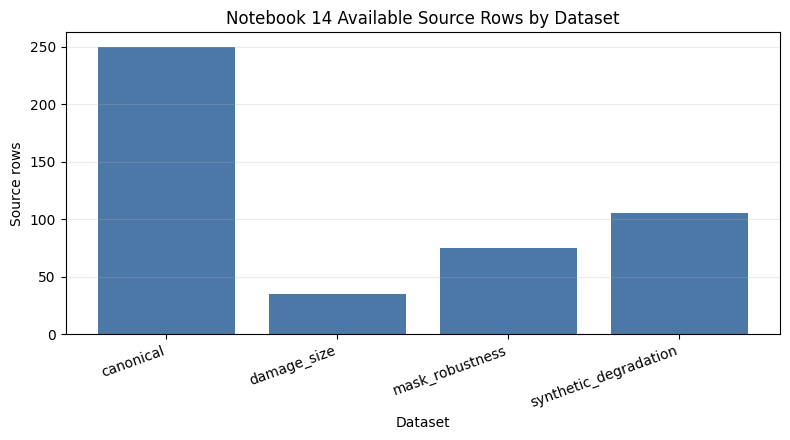

In [7]:
source_metadata_by_dataset: dict[str, pd.DataFrame] = {}

for dataset_name in included_dataset_names:
    metadata_path = resolved_input_paths[dataset_name]
    source_metadata_df = pd.read_csv(metadata_path)

    if source_metadata_df.empty:
        raise ValueError(f"{dataset_name} metadata is empty: {metadata_path}")

    source_metadata_by_dataset[dataset_name] = source_metadata_df


source_schema_rows = []
status_summary_rows = []

for dataset_name, source_metadata_df in source_metadata_by_dataset.items():
    candidate_columns = {
        "clean_path_candidates": ("clean_path", "processed_path", "image_path", "processed_image_path"),
        "damaged_path_candidates": ("damaged_path", "degraded_path", "synthetic_degraded_path", "masked_path"),
        "mask_path_candidates": ("mask_path", "sensitivity_mask_path", "effect_mask_path", "synthetic_effect_mask_path"),
        "status_columns": ("status", "generation_status", "validation_status"),
    }

    schema_row = {
        "dataset_name": dataset_name,
        "row_count": len(source_metadata_df),
        "column_count": len(source_metadata_df.columns),
        "has_case_id": "case_id" in source_metadata_df.columns,
        "has_painting_id": "painting_id" in source_metadata_df.columns,
    }

    for output_column, candidates in candidate_columns.items():
        schema_row[output_column] = ", ".join(
            column_name for column_name in candidates if column_name in source_metadata_df.columns
        )

    source_schema_rows.append(schema_row)

    if "status" in source_metadata_df.columns:
        status_counts = source_metadata_df["status"].fillna("missing").astype(str).value_counts(dropna=False)
        for status_value, status_count in status_counts.items():
            status_summary_rows.append(
                {
                    "dataset_name": dataset_name,
                    "status": status_value,
                    "row_count": int(status_count),
                }
            )

source_schema_df = pd.DataFrame(source_schema_rows)
source_status_summary_df = pd.DataFrame(status_summary_rows)

print("Source schema summary")
print("---------------------")
display(source_schema_df)

if not source_status_summary_df.empty:
    print("Source status summary")
    print("---------------------")
    display(source_status_summary_df)

plt.figure(figsize=(8, 4.5))
plt.bar(source_schema_df["dataset_name"], source_schema_df["row_count"], color="#4c78a8")
plt.ylabel("Source rows")
plt.xlabel("Dataset")
plt.title("Notebook 14 Available Source Rows by Dataset")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


In [8]:
dataset_applicability_policy_df = pd.DataFrame(
    [
        {
            "dataset_name": "canonical",
            "availability": "required",
            "include": "canonical" in included_dataset_names,
            "source_mask_semantics": "binary missing-content mask",
            "lama_mask_policy": f"Use source mask after helper threshold > {MASK_BINARY_THRESHOLD}.",
            "case_filter": "All valid canonical cases, including zero controls.",
            "methodological_role": "Primary learned inpainting branch.",
        },
        {
            "dataset_name": "damage_size",
            "availability": "required",
            "include": "damage_size" in included_dataset_names,
            "source_mask_semantics": "binary missing-content mask",
            "lama_mask_policy": f"Use source mask after helper threshold > {MASK_BINARY_THRESHOLD}.",
            "case_filter": "All valid matched damage-size cases.",
            "methodological_role": "Damage-size sensitivity branch.",
        },
        {
            "dataset_name": "mask_robustness",
            "availability": "optional",
            "include": "mask_robustness" in included_dataset_names,
            "source_mask_semantics": "binary missing-content mask",
            "lama_mask_policy": f"Use source mask after helper threshold > {MASK_BINARY_THRESHOLD}.",
            "case_filter": "All valid mask-robustness cases when metadata exists.",
            "methodological_role": "Mask geometry and placement robustness branch.",
        },
        {
            "dataset_name": "synthetic_degradation",
            "availability": "optional",
            "include": "synthetic_degradation" in included_dataset_names,
            "source_mask_semantics": "grayscale effect-intensity mask",
            "lama_mask_policy": f"Use source effect mask as a binary inpainting target after threshold > {MASK_BINARY_THRESHOLD}.",
            "case_filter": "Only localized effect types suitable for an inpainting-style intervention.",
            "methodological_role": "Supplementary method-behavior diagnostic, not pooled uncritically with missing-content cases.",
        },
    ]
)

synthetic_lama_policy_df = pd.DataFrame(
    [
        {
            "degradation_type": "water_stain",
            "include_for_lama": True,
            "reason": "Localized stain-like effect can be treated as a masked removal/inpainting diagnostic.",
        },
        {
            "degradation_type": "dirt_dust",
            "include_for_lama": True,
            "reason": "Localized dirt/dust support can be treated as a masked removal/inpainting diagnostic.",
        },
        {
            "degradation_type": "partial_transparency",
            "include_for_lama": True,
            "reason": "Localized transparency support can be treated as a masked inpainting-style diagnostic.",
        },
        {
            "degradation_type": "water_stain_dirt",
            "include_for_lama": True,
            "reason": "Combined localized stain/dirt support remains spatially mask-addressable.",
        },
        {
            "degradation_type": "blur",
            "include_for_lama": False,
            "reason": "Blur is not missing content and should be handled by degradation-specific analysis, not inpainting.",
        },
        {
            "degradation_type": "fading",
            "include_for_lama": False,
            "reason": "Fading is a global/tonal degradation, not a missing-content inpainting target.",
        },
        {
            "degradation_type": "discolouration",
            "include_for_lama": False,
            "reason": "Discolouration is a colour correction problem, not a LaMa missing-region task.",
        },
        {
            "degradation_type": "fading_discolouration",
            "include_for_lama": False,
            "reason": "Combined tonal/colour shift is not a suitable inpainting target.",
        },
        {
            "degradation_type": "blur_fading",
            "include_for_lama": False,
            "reason": "Combined blur/fading is not a suitable inpainting target.",
        },
    ]
)

print("Dataset applicability policy")
print("----------------------------")
display(dataset_applicability_policy_df)

print("Synthetic-degradation LaMa eligibility policy")
print("---------------------------------------------")
display(synthetic_lama_policy_df)


Dataset applicability policy
----------------------------


,dataset_name,availability,include,source_mask_semantics,lama_mask_policy,case_filter,methodological_role
0,canonical,required,True,binary missing-content mask,Use source mask after helper threshold > 127.,"All valid canonical cases, including zero cont...",Primary learned inpainting branch.
1,damage_size,required,True,binary missing-content mask,Use source mask after helper threshold > 127.,All valid matched damage-size cases.,Damage-size sensitivity branch.
2,mask_robustness,optional,True,binary missing-content mask,Use source mask after helper threshold > 127.,All valid mask-robustness cases when metadata ...,Mask geometry and placement robustness branch.
3,synthetic_degradation,optional,True,grayscale effect-intensity mask,Use source effect mask as a binary inpainting ...,Only localized effect types suitable for an in...,"Supplementary method-behavior diagnostic, not ..."


Synthetic-degradation LaMa eligibility policy
---------------------------------------------


,degradation_type,include_for_lama,reason
0,water_stain,True,Localized stain-like effect can be treated as ...
1,dirt_dust,True,Localized dirt/dust support can be treated as ...
2,partial_transparency,True,Localized transparency support can be treated ...
3,water_stain_dirt,True,Combined localized stain/dirt support remains ...
4,blur,False,Blur is not missing content and should be hand...
5,fading,False,"Fading is a global/tonal degradation, not a mi..."
6,discolouration,False,"Discolouration is a colour correction problem,..."
7,fading_discolouration,False,Combined tonal/colour shift is not a suitable ...
8,blur_fading,False,Combined blur/fading is not a suitable inpaint...


In [9]:
def accepted_status_mask(dataframe: pd.DataFrame) -> pd.Series:
    """Return rows whose upstream status is valid, or all rows if no status column exists."""
    if "status" not in dataframe.columns:
        return pd.Series(True, index=dataframe.index)

    accepted_values = {"ok", "success", "passed", "valid"}
    return dataframe["status"].fillna("").astype(str).str.strip().str.lower().isin(accepted_values)


def prepare_source_for_lama(source_metadata_df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    """Apply Notebook 14 dataset-level eligibility policy before helper normalization."""
    prepared_df = source_metadata_df.loc[accepted_status_mask(source_metadata_df)].copy()

    if dataset_name == "synthetic_degradation":
        if "degradation_type" not in prepared_df.columns:
            raise ValueError("Synthetic-degradation metadata must contain degradation_type.")

        included_types = set(SYNTHETIC_LAMA_DEGRADATION_TYPES)
        prepared_df = prepared_df.loc[
            prepared_df["degradation_type"].astype(str).isin(included_types)
        ].copy()

        prepared_df["source_mask_semantics"] = "grayscale_effect_intensity"
        prepared_df["lama_applicability"] = "supplementary_synthetic_degradation"
    else:
        prepared_df["source_mask_semantics"] = "binary_missing_content"
        prepared_df["lama_applicability"] = "primary"

    return prepared_df


normalized_input_frames = []
normalization_summary_rows = []

for dataset_name in included_dataset_names:
    prepared_source_df = prepare_source_for_lama(
        source_metadata_by_dataset[dataset_name],
        dataset_name,
    )

    if prepared_source_df.empty:
        if dataset_name in REQUIRED_DATASETS:
            raise RuntimeError(f"Required dataset has no eligible LaMa rows: {dataset_name}")

        normalization_summary_rows.append(
            {
                "dataset_name": dataset_name,
                "source_rows": len(source_metadata_by_dataset[dataset_name]),
                "eligible_rows": 0,
                "normalized_rows": 0,
                "decision": "skip_empty_after_policy",
            }
        )
        continue

    normalized_df = normalize_lama_restoration_input_manifest(
        prepared_source_df,
        dataset_name=dataset_name,
        source_metadata_path=project_relative_path(resolved_input_paths[dataset_name]),
        case_id_prefix=dataset_name,
    )

    normalized_input_frames.append(normalized_df)
    normalization_summary_rows.append(
        {
            "dataset_name": dataset_name,
            "source_rows": len(source_metadata_by_dataset[dataset_name]),
            "eligible_rows": len(prepared_source_df),
            "normalized_rows": len(normalized_df),
            "decision": "include",
        }
    )

if not normalized_input_frames:
    raise RuntimeError("No LaMa restoration input rows were normalized.")

lama_restoration_input_manifest_df = (
    pd.concat(normalized_input_frames, ignore_index=True)
    .sort_values(["dataset_name", "painting_id", "case_id"], kind="stable")
    .reset_index(drop=True)
)

normalization_summary_df = pd.DataFrame(normalization_summary_rows)

validate_restoration_input_manifest(lama_restoration_input_manifest_df)

print("LaMa restoration input normalization summary")
print("--------------------------------------------")
display(normalization_summary_df)

print("Normalized LaMa restoration input preview")
print("-----------------------------------------")
display(
    lama_restoration_input_manifest_df[
        [
            "dataset_name",
            "case_id",
            "source_case_id_original",
            "painting_id",
            "source_mask_semantics",
            "lama_applicability",
            "clean_path",
            "damaged_path",
            "mask_path",
        ]
    ].head(10)
)


LaMa restoration input normalization summary
--------------------------------------------


,dataset_name,source_rows,eligible_rows,normalized_rows,decision
0,canonical,250,250,250,include
1,damage_size,35,35,35,include
2,mask_robustness,75,75,75,include
3,synthetic_degradation,105,50,50,include


Normalized LaMa restoration input preview
-----------------------------------------


,dataset_name,case_id,source_case_id_original,painting_id,source_mask_semantics,lama_applicability,clean_path,damaged_path,mask_path
0,canonical,canonical__p001_loss_large,p001_loss_large,p001,binary_missing_content,primary,data\processed\clean\p001_clean.png,data\processed\masked\p001_loss_large_damaged.png,data\processed\masks\p001_loss_large_mask.png
1,canonical,canonical__p001_loss_small,p001_loss_small,p001,binary_missing_content,primary,data\processed\clean\p001_clean.png,data\processed\masked\p001_loss_small_damaged.png,data\processed\masks\p001_loss_small_mask.png
2,canonical,canonical__p001_mixed_damage,p001_mixed_damage,p001,binary_missing_content,primary,data\processed\clean\p001_clean.png,data\processed\masked\p001_mixed_damage_damage...,data\processed\masks\p001_mixed_damage_mask.png
3,canonical,canonical__p001_scratch_thin,p001_scratch_thin,p001,binary_missing_content,primary,data\processed\clean\p001_clean.png,data\processed\masked\p001_scratch_thin_damage...,data\processed\masks\p001_scratch_thin_mask.png
4,canonical,canonical__p001_zero_control,p001_zero_control,p001,binary_missing_content,primary,data\processed\clean\p001_clean.png,data\processed\masked\p001_zero_control_damage...,data\processed\masks\p001_zero_control_mask.png
5,canonical,canonical__p002_loss_large,p002_loss_large,p002,binary_missing_content,primary,data\processed\clean\p002_clean.png,data\processed\masked\p002_loss_large_damaged.png,data\processed\masks\p002_loss_large_mask.png
6,canonical,canonical__p002_loss_small,p002_loss_small,p002,binary_missing_content,primary,data\processed\clean\p002_clean.png,data\processed\masked\p002_loss_small_damaged.png,data\processed\masks\p002_loss_small_mask.png
7,canonical,canonical__p002_mixed_damage,p002_mixed_damage,p002,binary_missing_content,primary,data\processed\clean\p002_clean.png,data\processed\masked\p002_mixed_damage_damage...,data\processed\masks\p002_mixed_damage_mask.png
8,canonical,canonical__p002_scratch_thin,p002_scratch_thin,p002,binary_missing_content,primary,data\processed\clean\p002_clean.png,data\processed\masked\p002_scratch_thin_damage...,data\processed\masks\p002_scratch_thin_mask.png
9,canonical,canonical__p002_zero_control,p002_zero_control,p002,binary_missing_content,primary,data\processed\clean\p002_clean.png,data\processed\masked\p002_zero_control_damage...,data\processed\masks\p002_zero_control_mask.png


In [10]:
def path_exists(path_value: str | Path) -> bool:
    """Return whether a repository-relative or absolute path exists."""
    return resolve_project_path(path_value).is_file()


def read_mask_area(mask_path_value: str | Path, threshold: int = MASK_BINARY_THRESHOLD) -> int:
    """Count pixels above the LaMa binary mask threshold."""
    mask_path = resolve_project_path(mask_path_value)

    with Image.open(mask_path) as image:
        mask_array = np.asarray(image.convert("L"))

    return int((mask_array > threshold).sum())


path_validation_rows = []

for path_column in ("clean_path", "damaged_path", "mask_path"):
    exists_series = lama_restoration_input_manifest_df[path_column].map(path_exists)
    path_validation_rows.append(
        {
            "check": f"{path_column}_exists",
            "observed": int(exists_series.sum()),
            "expected": len(lama_restoration_input_manifest_df),
            "passed": bool(exists_series.all()),
        }
    )

source_case_key = (
    lama_restoration_input_manifest_df["dataset_name"].astype(str)
    + "__"
    + lama_restoration_input_manifest_df["case_id"].astype(str)
)

path_validation_rows.append(
    {
        "check": "dataset_case_ids_unique",
        "observed": int(source_case_key.nunique()),
        "expected": len(lama_restoration_input_manifest_df),
        "passed": bool(source_case_key.is_unique),
    }
)

path_validation_rows.append(
    {
        "check": "required_datasets_present",
        "observed": sorted(lama_restoration_input_manifest_df["dataset_name"].astype(str).unique()),
        "expected": sorted(REQUIRED_DATASETS),
        "passed": all(
            required_dataset in set(lama_restoration_input_manifest_df["dataset_name"].astype(str))
            for required_dataset in REQUIRED_DATASETS
        ),
    }
)

restoration_input_checks_df = pd.DataFrame(path_validation_rows)

failed_input_checks_df = restoration_input_checks_df.loc[
    ~restoration_input_checks_df["passed"].astype(bool)
].copy()

print("Restoration input checks")
print("------------------------")
display(restoration_input_checks_df)

if not failed_input_checks_df.empty:
    raise RuntimeError(
        "LaMa restoration input validation failed:\n"
        + failed_input_checks_df.to_string(index=False)
    )

lama_restoration_input_manifest_df["lama_mask_area_pixels"] = (
    lama_restoration_input_manifest_df["mask_path"].map(read_mask_area)
)

mask_area_summary_df = (
    lama_restoration_input_manifest_df.groupby(
        ["dataset_name", "source_mask_semantics", "lama_applicability"],
        dropna=False,
        sort=False,
    )
    .agg(
        case_count=("case_id", "count"),
        zero_mask_cases=("lama_mask_area_pixels", lambda values: int((values.astype(int) == 0).sum())),
        nonzero_mask_cases=("lama_mask_area_pixels", lambda values: int((values.astype(int) > 0).sum())),
        mean_mask_area_pixels=("lama_mask_area_pixels", "mean"),
        median_mask_area_pixels=("lama_mask_area_pixels", "median"),
        max_mask_area_pixels=("lama_mask_area_pixels", "max"),
    )
    .reset_index()
)

for column_name in ("mean_mask_area_pixels", "median_mask_area_pixels"):
    mask_area_summary_df[column_name] = mask_area_summary_df[column_name].astype(float).round(2)

print("LaMa mask area summary")
print("----------------------")
display(mask_area_summary_df)


Restoration input checks
------------------------


,check,observed,expected,passed
0,clean_path_exists,410,410,True
1,damaged_path_exists,410,410,True
2,mask_path_exists,410,410,True
3,dataset_case_ids_unique,410,410,True
4,required_datasets_present,"[canonical, damage_size, mask_robustness, synt...","[canonical, damage_size]",True


LaMa mask area summary
----------------------


,dataset_name,source_mask_semantics,lama_applicability,case_count,zero_mask_cases,nonzero_mask_cases,mean_mask_area_pixels,median_mask_area_pixels,max_mask_area_pixels
0,canonical,binary_missing_content,primary,250,50,200,25489.36,18344.5,83018
1,damage_size,binary_missing_content,primary,35,0,35,40987.97,34593.0,101967
2,mask_robustness,binary_missing_content,primary,75,0,75,27912.39,19494.0,63746
3,synthetic_degradation,grayscale_effect_intensity,supplementary_synthetic_degradation,50,5,45,37288.96,13484.5,315211


Expected LaMa restoration counts
--------------------------------


,dataset_name,expected_restoration_count
0,canonical,250
1,damage_size,35
2,mask_robustness,75
3,synthetic_degradation,50


Expected restoration manifest checks
------------------------------------


,check,observed,expected,passed
0,expected_restoration_manifest_nonempty,410,> 0,True
1,restoration_case_ids_unique,410,410,True
2,expected_output_paths_unique,410,410,True


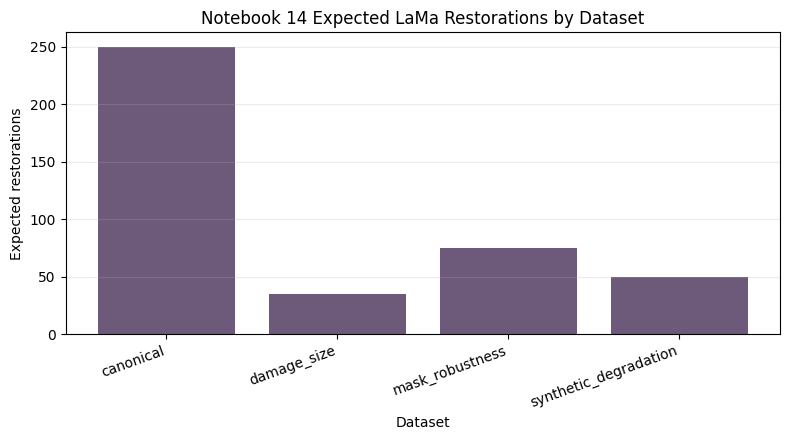

In [11]:
expected_restoration_manifest_df = (
    lama_restoration_input_manifest_df[
        [
            "dataset_name",
            "case_id",
            "source_case_id_original",
            "painting_id",
            "clean_path",
            "damaged_path",
            "mask_path",
            "source_mask_semantics",
            "lama_applicability",
            "source_metadata_path",
            "lama_mask_area_pixels",
        ]
    ]
    .copy()
)

expected_restoration_manifest_df["restoration_case_id"] = (
    MODEL_NAME
    + "__"
    + expected_restoration_manifest_df["dataset_name"].astype(str)
    + "__"
    + expected_restoration_manifest_df["case_id"].astype(str)
)

expected_restoration_manifest_df["restored_filename"] = (
    expected_restoration_manifest_df["case_id"].astype(str)
    + "_restored_"
    + MODEL_NAME
    + ".png"
)

expected_restoration_manifest_df["expected_restored_path"] = expected_restoration_manifest_df.apply(
    lambda row: project_relative_path(
        restored_root_dir / str(row["dataset_name"]) / str(row["restored_filename"])
    ),
    axis=1,
)

expected_total_restoration_count = len(expected_restoration_manifest_df)
expected_dataset_counts_df = (
    expected_restoration_manifest_df.groupby("dataset_name", dropna=False, sort=False)
    .size()
    .reset_index(name="expected_restoration_count")
)

expected_restoration_checks_df = pd.DataFrame(
    [
        {
            "check": "expected_restoration_manifest_nonempty",
            "observed": expected_total_restoration_count,
            "expected": "> 0",
            "passed": expected_total_restoration_count > 0,
        },
        {
            "check": "restoration_case_ids_unique",
            "observed": int(expected_restoration_manifest_df["restoration_case_id"].nunique()),
            "expected": expected_total_restoration_count,
            "passed": expected_restoration_manifest_df["restoration_case_id"].is_unique,
        },
        {
            "check": "expected_output_paths_unique",
            "observed": int(expected_restoration_manifest_df["expected_restored_path"].nunique()),
            "expected": expected_total_restoration_count,
            "passed": expected_restoration_manifest_df["expected_restored_path"].is_unique,
        },
    ]
)

print("Expected LaMa restoration counts")
print("--------------------------------")
display(expected_dataset_counts_df)

print("Expected restoration manifest checks")
print("------------------------------------")
display(expected_restoration_checks_df)

plt.figure(figsize=(8, 4.5))
plt.bar(
    expected_dataset_counts_df["dataset_name"],
    expected_dataset_counts_df["expected_restoration_count"],
    color="#6d597a",
)
plt.ylabel("Expected restorations")
plt.xlabel("Dataset")
plt.title("Notebook 14 Expected LaMa Restorations by Dataset")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

failed_expected_checks_df = expected_restoration_checks_df.loc[
    ~expected_restoration_checks_df["passed"].astype(bool)
].copy()

if not failed_expected_checks_df.empty:
    raise RuntimeError(
        "Expected LaMa restoration manifest checks failed:\n"
        + failed_expected_checks_df.to_string(index=False)
    )


In [12]:
# Batch 2: LaMa smoke-test setup

SMOKE_CASES_PER_DATASET = 1
SMOKE_INCLUDE_ZERO_CONTROL = True

smoke_restored_root_dir = temporary_smoke_test_dir
smoke_staging_root = lama_staging_root / "smoke_test_staging"

if smoke_restored_root_dir.exists():
    shutil.rmtree(smoke_restored_root_dir)

if smoke_staging_root.exists():
    shutil.rmtree(smoke_staging_root)

smoke_restored_root_dir.mkdir(parents=True, exist_ok=True)
smoke_staging_root.mkdir(parents=True, exist_ok=True)

effective_lama_device = LAMA_DEVICE

if (
    str(LAMA_DEVICE).lower() == "cuda"
    and not bool(lama_runtime_environment.get("cuda_available", False))
):
    effective_lama_device = "cpu"
    display(
        Markdown(
            "**CUDA is not available in this environment.** "
            "The smoke test will use `cpu`. If your notebook runtime has GPU, "
            "restart the kernel there and rerun Batch 1 before this batch."
        )
    )

if not shutil.which(LAMA_EXECUTABLE):
    raise RuntimeError(
        f"`{LAMA_EXECUTABLE}` executable was not found. "
        "Install/activate IOPaint before running LaMa inference."
    )

print("Smoke restored root:", project_relative_path(smoke_restored_root_dir))
print("Smoke staging root:", project_relative_path(smoke_staging_root))
print("Effective LaMa device:", effective_lama_device)

Smoke restored root: outputs/tmp/14_lama_restoration/smoke_test_restored
Smoke staging root: outputs/tmp/14_lama_restoration/smoke_test_staging
Effective LaMa device: cuda


In [13]:
# Batch 2: choose a small, representative smoke-test subset

def is_zero_control_candidate(dataframe: pd.DataFrame) -> pd.Series:
    """Detect zero-control rows from mask area or mask-type metadata."""
    zero_mask = dataframe["lama_mask_area_pixels"].fillna(-1).astype(int).eq(0)

    mask_type_columns = [
        column
        for column in ("mask_type", "base_mask_type", "report_mask_type")
        if column in dataframe.columns
    ]

    if not mask_type_columns:
        return zero_mask

    mask_type_zero = pd.Series(False, index=dataframe.index)

    for column in mask_type_columns:
        mask_type_zero = mask_type_zero | dataframe[column].fillna("").astype(str).eq("zero_control")

    return zero_mask | mask_type_zero


smoke_selection_rows = []
smoke_selected_frames = []

zero_control_mask = is_zero_control_candidate(lama_restoration_input_manifest_df)

if SMOKE_INCLUDE_ZERO_CONTROL and zero_control_mask.any():
    zero_control_row = (
        lama_restoration_input_manifest_df.loc[zero_control_mask]
        .sort_values(["dataset_name", "painting_id", "case_id"], kind="stable")
        .head(1)
    )
    smoke_selected_frames.append(zero_control_row)
    smoke_selection_rows.append(
        {
            "selection_group": "zero_control",
            "dataset_name": str(zero_control_row.iloc[0]["dataset_name"]),
            "case_id": str(zero_control_row.iloc[0]["case_id"]),
            "reason": "Verify zero-control copy path without model inference.",
        }
    )

nonzero_candidates_df = lama_restoration_input_manifest_df.loc[~zero_control_mask].copy()

for dataset_name, dataset_df in nonzero_candidates_df.groupby("dataset_name", sort=False):
    selected_df = (
        dataset_df.sort_values(
            ["lama_mask_area_pixels", "painting_id", "case_id"],
            ascending=[False, True, True],
            kind="stable",
        )
        .head(SMOKE_CASES_PER_DATASET)
    )

    if selected_df.empty:
        continue

    smoke_selected_frames.append(selected_df)

    for _, row in selected_df.iterrows():
        smoke_selection_rows.append(
            {
                "selection_group": "nonzero_dataset_probe",
                "dataset_name": str(row["dataset_name"]),
                "case_id": str(row["case_id"]),
                "reason": "Largest-mask eligible case for this dataset branch.",
            }
        )

if not smoke_selected_frames:
    raise RuntimeError("No smoke-test rows could be selected.")

lama_smoke_input_df = (
    pd.concat(smoke_selected_frames, ignore_index=True)
    .drop_duplicates(subset=["dataset_name", "case_id"], keep="first")
    .sort_values(["dataset_name", "painting_id", "case_id"], kind="stable")
    .reset_index(drop=True)
)

smoke_selection_df = pd.DataFrame(smoke_selection_rows)

print("Selected LaMa smoke-test cases")
print("------------------------------")
display(smoke_selection_df)

display(
    lama_smoke_input_df[
        [
            "dataset_name",
            "case_id",
            "painting_id",
            "source_case_id_original",
            "source_mask_semantics",
            "lama_applicability",
            "lama_mask_area_pixels",
            "clean_path",
            "damaged_path",
            "mask_path",
        ]
    ]
)

Selected LaMa smoke-test cases
------------------------------


,selection_group,dataset_name,case_id,reason
0,zero_control,canonical,canonical__p001_zero_control,Verify zero-control copy path without model in...
1,nonzero_dataset_probe,canonical,canonical__p031_loss_large,Largest-mask eligible case for this dataset br...
2,nonzero_dataset_probe,damage_size,damage_size__p001__loss_large__size_20pct,Largest-mask eligible case for this dataset br...
3,nonzero_dataset_probe,mask_robustness,mask_robustness__p001__loss_large__variant_02,Largest-mask eligible case for this dataset br...
4,nonzero_dataset_probe,synthetic_degradation,synthetic_degradation__p001__partial_transpare...,Largest-mask eligible case for this dataset br...


,dataset_name,case_id,painting_id,source_case_id_original,source_mask_semantics,lama_applicability,lama_mask_area_pixels,clean_path,damaged_path,mask_path
0,canonical,canonical__p001_zero_control,p001,p001_zero_control,binary_missing_content,primary,0,data\processed\clean\p001_clean.png,data\processed\masked\p001_zero_control_damage...,data\processed\masks\p001_zero_control_mask.png
1,canonical,canonical__p031_loss_large,p031,p031_loss_large,binary_missing_content,primary,83018,data\processed\clean\p031_clean.png,data\processed\masked\p031_loss_large_damaged.png,data\processed\masks\p031_loss_large_mask.png
2,damage_size,damage_size__p001__loss_large__size_20pct,p001,p001__loss_large__size_20pct,binary_missing_content,primary,101967,data/processed/clean/p001_clean.png,data/processed/damaged/damage_size_sensitivity...,data/processed/masks/damage_size_sensitivity/p...
3,mask_robustness,mask_robustness__p001__loss_large__variant_02,p001,p001__loss_large__variant_02,binary_missing_content,primary,63746,data/processed/clean/p001_clean.png,data/processed/damaged/mask_robustness/p001__l...,data/processed/masks/mask_robustness/p001__los...
4,synthetic_degradation,synthetic_degradation__p001__partial_transpare...,p001,p001__partial_transparency__severe,grayscale_effect_intensity,supplementary_synthetic_degradation,315211,data/processed/clean/p001_clean.png,data/processed/degraded/synthetic_degradation/...,data/processed/masks/synthetic_degradation/p00...


In [14]:
# Batch 2: run LaMa smoke-test restorations

lama_smoke_restored_metadata_df = create_lama_restoration_dataset(
    lama_smoke_input_df,
    smoke_restored_root_dir,
    staging_root=smoke_staging_root,
    project_root=PROJECT_ROOT,
    model_name=MODEL_NAME,
    iopaint_model_name=IOPAINT_MODEL_NAME,
    device=effective_lama_device,
    executable=LAMA_EXECUTABLE,
    mask_threshold=MASK_BINARY_THRESHOLD,
    overwrite=True,
    max_retries=LAMA_MAX_RETRIES,
    retry_delay_seconds=LAMA_RETRY_DELAY_SECONDS,
    compute_checksums=COMPUTE_CHECKSUMS,
    cleanup_staging=False,
    progress_every=1,
)

lama_smoke_summary_df = summarize_lama_restoration(lama_smoke_restored_metadata_df)

print("LaMa smoke-test execution summary")
print("---------------------------------")
display(lama_smoke_summary_df)

display(
    lama_smoke_restored_metadata_df[
        [
            "restoration_case_id",
            "dataset_name",
            "case_id",
            "painting_id",
            "restoration_method",
            "inference_mode",
            "execution_device",
            "runtime_seconds",
            "retry_count",
            "attempt_count",
            "status",
            "issue",
            "restored_path",
        ]
    ]
)

failed_smoke_rows_df = lama_smoke_restored_metadata_df.loc[
    lama_smoke_restored_metadata_df["status"].astype(str).ne("ok")
].copy()

if not failed_smoke_rows_df.empty:
    raise RuntimeError(
        "LaMa smoke test failed for one or more rows:\n"
        + failed_smoke_rows_df[
            [
                "restoration_case_id",
                "dataset_name",
                "case_id",
                "status",
                "issue",
                "iopaint_stderr_log_path",
            ]
        ].to_string(index=False)
    )

Running LaMa restoration case 1/5
Running LaMa restoration case 2/5
Running LaMa restoration case 3/5
Running LaMa restoration case 4/5
Running LaMa restoration case 5/5
LaMa smoke-test execution summary
---------------------------------


,dataset_name,input_cases,successful_cases,failed_cases,total_runtime_seconds,mean_runtime_seconds,median_runtime_seconds,max_runtime_seconds,total_retries
0,canonical,2,2,0,21.965570,10.982785,10.982785,21.965570,0
1,damage_size,1,1,0,19.490151,19.490151,19.490151,19.490151,0
2,mask_robustness,1,1,0,19.209893,19.209893,19.209893,19.209893,0
3,synthetic_degradation,1,1,0,19.553166,19.553166,19.553166,19.553166,0


,restoration_case_id,dataset_name,case_id,painting_id,restoration_method,inference_mode,execution_device,runtime_seconds,retry_count,attempt_count,status,issue,restored_path
0,lama__canonical__canonical__p001_zero_control,canonical,canonical__p001_zero_control,p001,zero_control_copy,copied_zero_control,cuda,0.000000,0,0,ok,,outputs\tmp\14_lama_restoration\smoke_test_res...
1,lama__canonical__canonical__p031_loss_large,canonical,canonical__p031_loss_large,p031,iopaint_lama,model_inference,cuda,21.965570,0,1,ok,,outputs\tmp\14_lama_restoration\smoke_test_res...
2,lama__damage_size__damage_size__p001__loss_lar...,damage_size,damage_size__p001__loss_large__size_20pct,p001,iopaint_lama,model_inference,cuda,19.490151,0,1,ok,,outputs\tmp\14_lama_restoration\smoke_test_res...
3,lama__mask_robustness__mask_robustness__p001__...,mask_robustness,mask_robustness__p001__loss_large__variant_02,p001,iopaint_lama,model_inference,cuda,19.209893,0,1,ok,,outputs\tmp\14_lama_restoration\smoke_test_res...
4,lama__synthetic_degradation__synthetic_degrada...,synthetic_degradation,synthetic_degradation__p001__partial_transpare...,p001,iopaint_lama,model_inference,cuda,19.553166,0,1,ok,,outputs\tmp\14_lama_restoration\smoke_test_res...


In [15]:
# Batch 2: validate smoke-test restored files and basic behavior

lama_smoke_file_validation_df = validate_restored_images(
    lama_smoke_restored_metadata_df,
    project_root=PROJECT_ROOT,
    target_size=TARGET_SIZE,
)

lama_smoke_behavior_validation_df = validate_lama_restoration_behavior(
    lama_smoke_restored_metadata_df,
    project_root=PROJECT_ROOT,
    target_size=TARGET_SIZE,
    mask_threshold=MASK_BINARY_THRESHOLD,
    enforce_outside_mask_preservation=False,
)

lama_smoke_inventory_audit_df = audit_lama_restoration_inventory(
    lama_smoke_restored_metadata_df,
    smoke_restored_root_dir,
    project_root=PROJECT_ROOT,
)

lama_smoke_audit_df = build_lama_restoration_audit_table(
    restored_metadata=lama_smoke_restored_metadata_df,
    file_validation=lama_smoke_file_validation_df,
    behavior_validation=lama_smoke_behavior_validation_df,
    inventory_audit=lama_smoke_inventory_audit_df,
    expected_dataset_names=sorted(lama_smoke_restored_metadata_df["dataset_name"].astype(str).unique()),
    notebook="14_lama_restoration_smoke_test",
    model_name=MODEL_NAME,
)

print("Smoke file validation")
print("---------------------")
display(lama_smoke_file_validation_df)

print("Smoke behavior validation")
print("-------------------------")
display(lama_smoke_behavior_validation_df)

print("Smoke inventory audit")
print("---------------------")
display(lama_smoke_inventory_audit_df)

print("Smoke audit checks")
print("------------------")
display(lama_smoke_audit_df)

failed_smoke_audit_df = lama_smoke_audit_df.loc[
    ~lama_smoke_audit_df["passed"].astype(bool)
].copy()

if not failed_smoke_audit_df.empty:
    raise RuntimeError(
        "LaMa smoke-test validation failed:\n"
        + failed_smoke_audit_df.to_string(index=False)
    )

Smoke file validation
---------------------


,restoration_case_id,dataset_name,case_id,painting_id,restored_path,file_exists,readable,width,height,mode,checksum_matches,validation_passed,issue
0,lama__canonical__canonical__p001_zero_control,canonical,canonical__p001_zero_control,p001,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,
1,lama__canonical__canonical__p031_loss_large,canonical,canonical__p031_loss_large,p031,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,
2,lama__damage_size__damage_size__p001__loss_lar...,damage_size,damage_size__p001__loss_large__size_20pct,p001,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,
3,lama__mask_robustness__mask_robustness__p001__...,mask_robustness,mask_robustness__p001__loss_large__variant_02,p001,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,
4,lama__synthetic_degradation__synthetic_degrada...,synthetic_degradation,synthetic_degradation__p001__partial_transpare...,p001,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,


Smoke behavior validation
-------------------------


,restoration_case_id,dataset_name,case_id,painting_id,mask_area_pixels,changed_pixels_vs_damaged,changed_pixels_inside_mask,changed_pixels_outside_mask,outside_mask_preserved,empty_mask_unchanged,nonempty_mask_changed,outside_mask_preservation_enforced,behavior_validation_passed,issue
0,lama__canonical__canonical__p001_zero_control,canonical,canonical__p001_zero_control,p001,0,0,0,0,True,True,None,False,True,
1,lama__canonical__canonical__p031_loss_large,canonical,canonical__p031_loss_large,p031,83018,83018,83018,0,True,None,True,False,True,
2,lama__damage_size__damage_size__p001__loss_lar...,damage_size,damage_size__p001__loss_large__size_20pct,p001,101967,101967,101967,0,True,None,True,False,True,
3,lama__mask_robustness__mask_robustness__p001__...,mask_robustness,mask_robustness__p001__loss_large__variant_02,p001,63746,63746,63746,0,True,None,True,False,True,
4,lama__synthetic_degradation__synthetic_degrada...,synthetic_degradation,synthetic_degradation__p001__partial_transpare...,p001,315211,314879,314879,0,True,None,True,False,True,


Smoke inventory audit
---------------------


,record_type,restoration_case_id,dataset_name,restored_path,exists,unexpected,inventory_passed,issue
0,expected,lama__canonical__canonical__p001_zero_control,canonical,D:\Masters\FH\Thesis\painting-restoration-eval...,True,False,True,
1,expected,lama__canonical__canonical__p031_loss_large,canonical,D:\Masters\FH\Thesis\painting-restoration-eval...,True,False,True,
2,expected,lama__damage_size__damage_size__p001__loss_lar...,damage_size,D:\Masters\FH\Thesis\painting-restoration-eval...,True,False,True,
3,expected,lama__mask_robustness__mask_robustness__p001__...,mask_robustness,D:\Masters\FH\Thesis\painting-restoration-eval...,True,False,True,
4,expected,lama__synthetic_degradation__synthetic_degrada...,synthetic_degradation,D:\Masters\FH\Thesis\painting-restoration-eval...,True,False,True,


Smoke audit checks
------------------


,notebook,model_name,generated_at_utc,audit_section,check,observed,expected,passed
0,14_lama_restoration_smoke_test,lama,2026-07-27T22:46:21.194922+00:00,restoration_execution,total_rows,5,>=1,True
1,14_lama_restoration_smoke_test,lama,2026-07-27T22:46:21.194922+00:00,restoration_execution,failed_rows,0,0,True
2,14_lama_restoration_smoke_test,lama,2026-07-27T22:46:21.194922+00:00,restoration_execution,dataset_names,"[canonical, damage_size, mask_robustness, synt...","[canonical, damage_size, mask_robustness, synt...",True
3,14_lama_restoration_smoke_test,lama,2026-07-27T22:46:21.194922+00:00,file_validation,failed_file_validations,0,0,True
4,14_lama_restoration_smoke_test,lama,2026-07-27T22:46:21.194922+00:00,behavior_validation,failed_behavior_validations,0,0,True
5,14_lama_restoration_smoke_test,lama,2026-07-27T22:46:21.194922+00:00,inventory,failed_inventory_rows,0,0,True


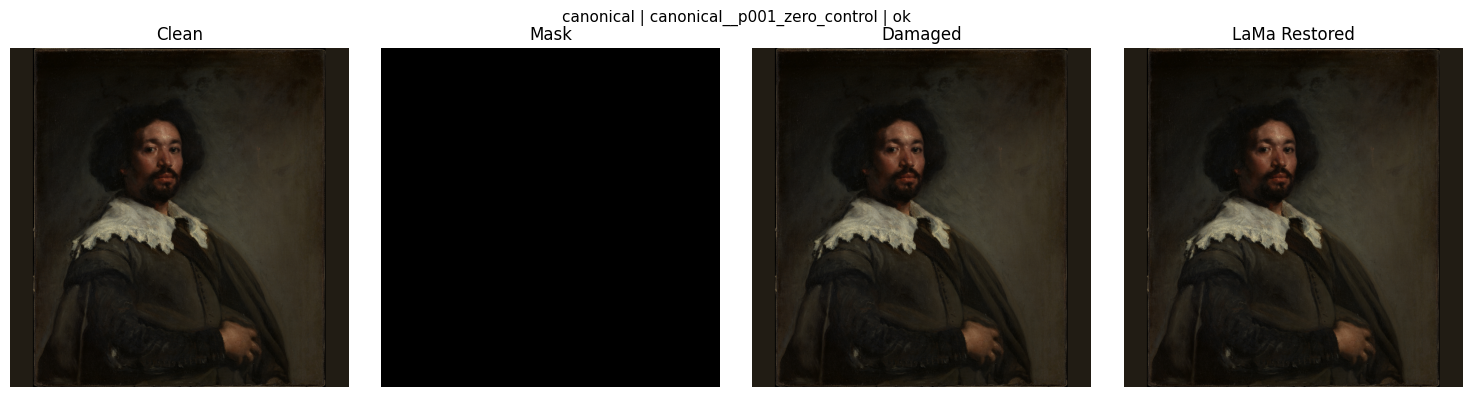

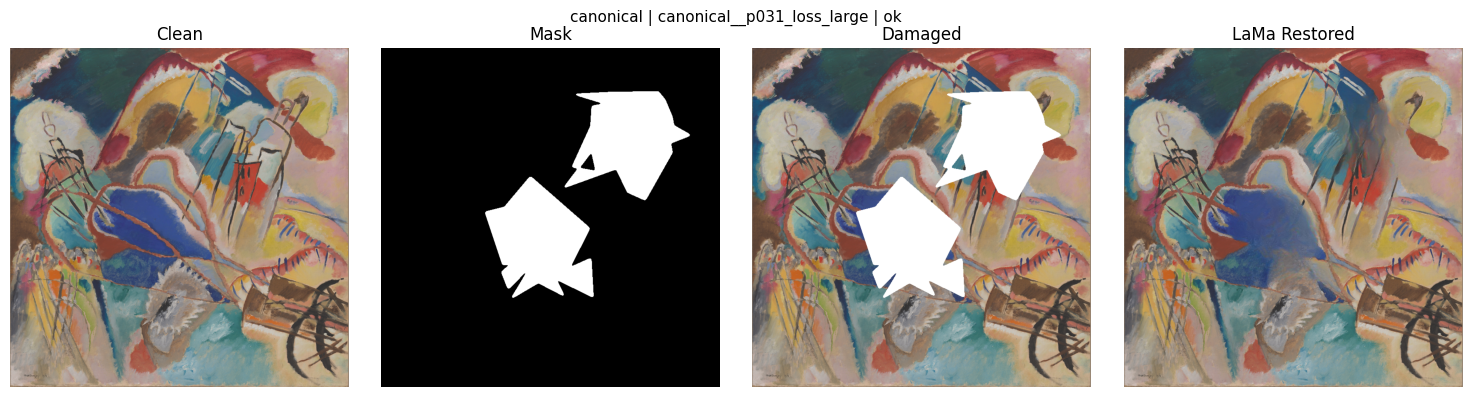

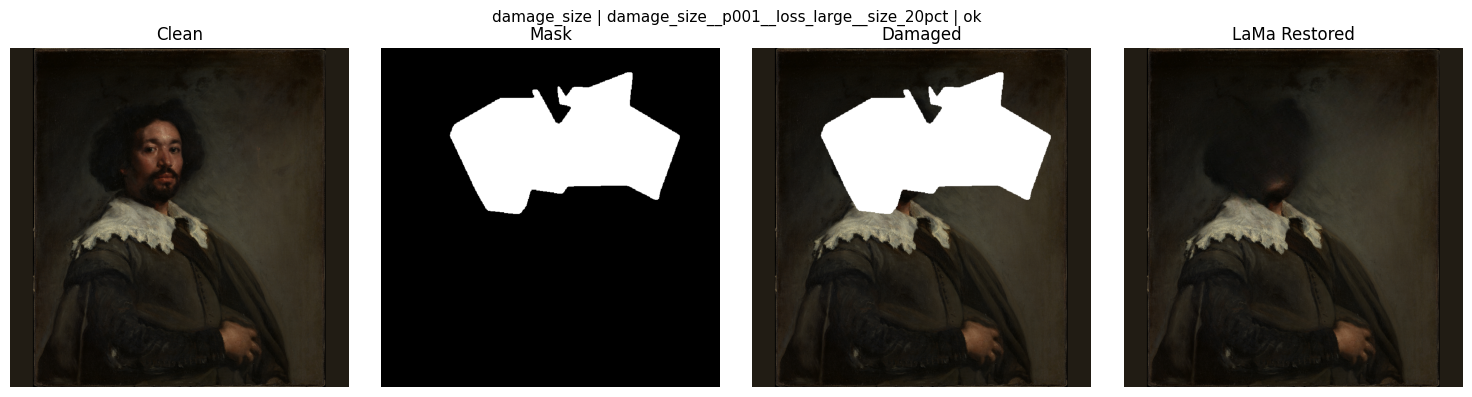

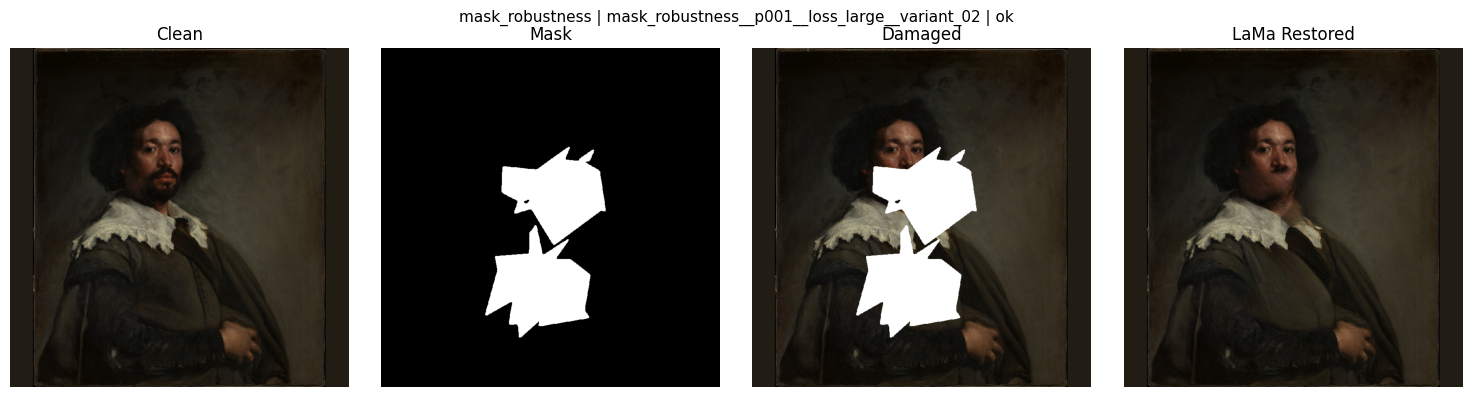

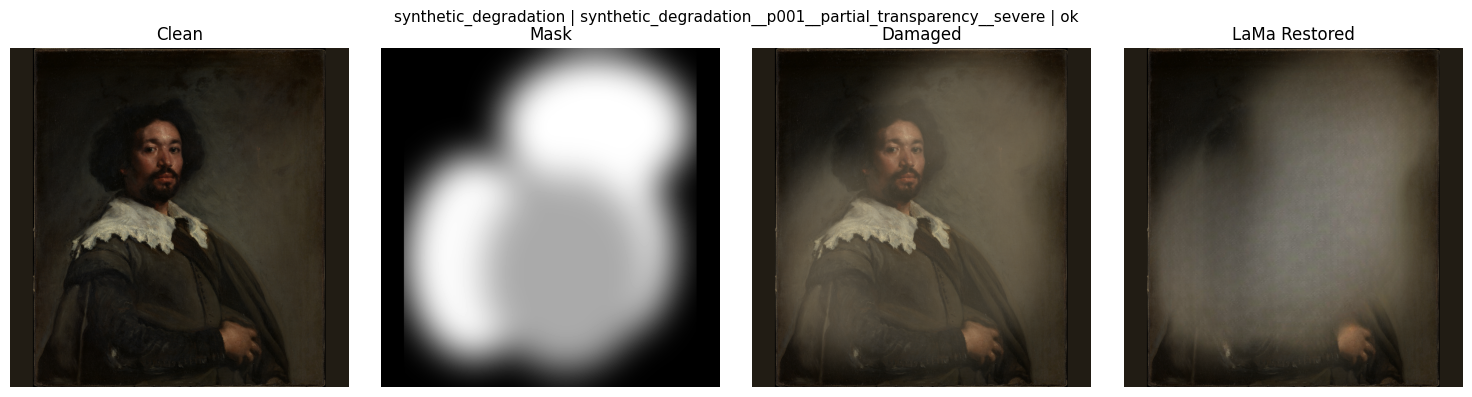

In [16]:
# Batch 2: render smoke-test visual panels in notebook

def load_rgb_image_for_display(path_value: str | Path) -> np.ndarray:
    with Image.open(resolve_project_path(path_value)) as image:
        return np.asarray(image.convert("RGB"))


def load_mask_for_display(path_value: str | Path) -> np.ndarray:
    with Image.open(resolve_project_path(path_value)) as image:
        return np.asarray(image.convert("L"))


def show_lama_case_panel(row: pd.Series) -> None:
    clean_image = load_rgb_image_for_display(row["clean_path"])
    damaged_image = load_rgb_image_for_display(row["damaged_path"])
    mask_image = load_mask_for_display(row["mask_path"])
    restored_image = load_rgb_image_for_display(row["restored_path"])

    fig, axes = plt.subplots(1, 4, figsize=(15, 4))

    panel_items = [
        ("Clean", clean_image, None),
        ("Mask", mask_image, "gray"),
        ("Damaged", damaged_image, None),
        ("LaMa Restored", restored_image, None),
    ]

    for axis, (title, image_array, cmap) in zip(axes, panel_items):
        axis.imshow(image_array, cmap=cmap)
        axis.set_title(title)
        axis.axis("off")

    fig.suptitle(
        f"{row['dataset_name']} | {row['case_id']} | {row['status']}",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()


for _, smoke_row in lama_smoke_restored_metadata_df.iterrows():
    show_lama_case_panel(smoke_row)

In [17]:
# Batch 3 replacement: batch-mode LaMa restoration setup and cleanup

from restoration_eval.restoration_lama import (
    calculate_file_sha256,
    collect_lama_batch_outputs,
    copy_zero_control_outputs,
    prepare_lama_batch_staging,
    run_iopaint_lama_batch,
)

lama_full_staging_root = PROJECT_ROOT / "outputs" / "tmp" / "lama_batch_full"

if "effective_lama_device" not in globals():
    effective_lama_device = LAMA_DEVICE

    if (
        str(LAMA_DEVICE).lower() == "cuda"
        and not bool(lama_runtime_environment.get("cuda_available", False))
    ):
        effective_lama_device = "cpu"

if not shutil.which(LAMA_EXECUTABLE):
    raise RuntimeError(
        f"`{LAMA_EXECUTABLE}` executable was not found. "
        "Install/activate IOPaint before running the full LaMa restoration batch."
    )

owned_paths_to_reset = [
    restored_root_dir,
    lama_full_staging_root,
]

owned_files_to_remove = [
    lama_metadata_path,
    lama_audit_path,
]

for path in owned_paths_to_reset:
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

for path in owned_files_to_remove:
    if path.exists():
        path.unlink()

lama_metadata_path.parent.mkdir(parents=True, exist_ok=True)
lama_audit_path.parent.mkdir(parents=True, exist_ok=True)

print("Full LaMa restored root:", project_relative_path(restored_root_dir))
print("Full LaMa batch staging root:", project_relative_path(lama_full_staging_root))
print("Effective LaMa device:", effective_lama_device)
print("Expected full-run cases:", len(lama_restoration_input_manifest_df))

Full LaMa restored root: data/processed/restored/lama
Full LaMa batch staging root: outputs/tmp/lama_batch_full
Effective LaMa device: cuda
Expected full-run cases: 410


In [18]:
# Batch 3 replacement: run one IOPaint batch command for all non-zero cases

def storage_log_path(path_value: object) -> str:
    if path_value is None or not str(path_value).strip():
        return ""
    return project_relative_path(Path(str(path_value)))


def standardize_batch_lama_metadata(
    restored_df: pd.DataFrame,
    *,
    batch_run_info: dict,
    effective_device: str,
) -> pd.DataFrame:
    standardized_df = restored_df.copy()

    runtime_environment = get_lama_runtime_environment(
        device=effective_device,
        executable=LAMA_EXECUTABLE,
        iopaint_model_name=IOPAINT_MODEL_NAME,
    )

    standardized_df["restoration_case_id"] = (
        MODEL_NAME
        + "__"
        + standardized_df["dataset_name"].astype(str)
        + "__"
        + standardized_df["case_id"].astype(str)
    )

    standardized_df["source_case_id"] = standardized_df["case_id"].astype(str)

    if "source_case_id_original" not in standardized_df.columns:
        standardized_df["source_case_id_original"] = standardized_df["case_id"].astype(str)

    standardized_df["model_name"] = MODEL_NAME
    standardized_df["iopaint_model_name"] = IOPAINT_MODEL_NAME
    standardized_df["iopaint_package_version"] = runtime_environment["iopaint_package_version"]
    standardized_df["lama_model_version"] = runtime_environment["lama_model_version"]
    standardized_df["restoration_generator_name"] = RESTORATION_GENERATOR_NAME
    standardized_df["restoration_generator_version"] = RESTORATION_GENERATOR_VERSION
    standardized_df["execution_device"] = effective_device
    standardized_df["execution_backend"] = runtime_environment["execution_backend"]
    standardized_df["operating_system"] = runtime_environment["operating_system"]
    standardized_df["processor"] = runtime_environment["processor"]
    standardized_df["machine"] = runtime_environment["machine"]
    standardized_df["python_version"] = runtime_environment["python_version"]
    standardized_df["torch_version"] = runtime_environment["torch_version"]
    standardized_df["cuda_available"] = runtime_environment["cuda_available"]
    standardized_df["cuda_device_count"] = runtime_environment["cuda_device_count"]
    standardized_df["cuda_device_name"] = runtime_environment["cuda_device_name"]
    standardized_df["cuda_runtime_version"] = runtime_environment["cuda_runtime_version"]

    model_mask = standardized_df["inference_mode"].astype(str).eq("model_inference")
    model_case_count = int(model_mask.sum())
    batch_runtime_seconds = float(batch_run_info.get("runtime_seconds", 0.0) or 0.0)

    standardized_df["batch_runtime_seconds"] = 0.0
    standardized_df.loc[model_mask, "batch_runtime_seconds"] = batch_runtime_seconds

    if model_case_count > 0:
        standardized_df.loc[model_mask, "runtime_seconds"] = (
            batch_runtime_seconds / model_case_count
        )

    standardized_df.loc[~model_mask, "runtime_seconds"] = (
        standardized_df.loc[~model_mask, "runtime_seconds"].fillna(0.0)
    )

    standardized_df["retry_count"] = 0
    standardized_df["attempt_count"] = np.where(model_mask, 1, 0)
    standardized_df["iopaint_returncode"] = np.where(
        model_mask,
        int(batch_run_info.get("returncode", 0)),
        0,
    )
    standardized_df["iopaint_command"] = np.where(
        model_mask,
        str(batch_run_info.get("command_text", "")),
        "",
    )
    standardized_df["iopaint_command_log_path"] = np.where(
        model_mask,
        storage_log_path(batch_run_info.get("command_log_path", "")),
        "",
    )
    standardized_df["iopaint_stdout_log_path"] = np.where(
        model_mask,
        storage_log_path(batch_run_info.get("stdout_log_path", "")),
        "",
    )
    standardized_df["iopaint_stderr_log_path"] = np.where(
        model_mask,
        storage_log_path(batch_run_info.get("stderr_log_path", "")),
        "",
    )

    standardized_df["mask_threshold"] = int(MASK_BINARY_THRESHOLD)

    if "mask_area_pixels" not in standardized_df.columns:
        standardized_df["mask_area_pixels"] = standardized_df.get(
            "lama_mask_area_pixels",
            pd.Series(np.nan, index=standardized_df.index),
        )

    for column_name in (
        "lama_staged_input_path",
        "lama_staged_mask_path",
        "lama_staged_output_path",
    ):
        if column_name not in standardized_df.columns:
            standardized_df[column_name] = ""
        standardized_df[column_name] = standardized_df[column_name].fillna("").astype(str)

    standardized_df["started_at_utc"] = np.where(
        model_mask,
        str(batch_run_info.get("started_at_utc", full_run_started_at_utc)),
        full_run_started_at_utc,
    )
    standardized_df["completed_at_utc"] = np.where(
        model_mask,
        str(batch_run_info.get("completed_at_utc", full_run_finished_at_utc)),
        full_run_finished_at_utc,
    )

    standardized_df["output_written"] = (
        standardized_df["status"].astype(str).eq("ok")
        & standardized_df["restored_path"].fillna("").astype(str).ne("")
    )

    standardized_df["restored_sha256"] = ""

    if COMPUTE_CHECKSUMS:
        checksum_values = []

        for _, row in standardized_df.iterrows():
            if str(row.get("status", "")) != "ok":
                checksum_values.append("")
                continue

            restored_path_value = str(row.get("restored_path", "")).strip()

            if not restored_path_value:
                checksum_values.append("")
                continue

            restored_path = resolve_project_path(restored_path_value)
            checksum_values.append(
                calculate_file_sha256(restored_path)
                if restored_path.is_file()
                else ""
            )

        standardized_df["restored_sha256"] = checksum_values

    leading_columns = [
        "restoration_case_id",
        "model_name",
        "iopaint_model_name",
        "iopaint_package_version",
        "lama_model_version",
        "restoration_method",
        "inference_mode",
        "restoration_generator_name",
        "restoration_generator_version",
        "execution_device",
        "execution_backend",
        "operating_system",
        "processor",
        "machine",
        "python_version",
        "torch_version",
        "cuda_available",
        "cuda_device_count",
        "cuda_device_name",
        "cuda_runtime_version",
        "retry_count",
        "attempt_count",
        "iopaint_returncode",
        "iopaint_command",
        "iopaint_command_log_path",
        "iopaint_stdout_log_path",
        "iopaint_stderr_log_path",
        "dataset_name",
        "source_case_id",
        "source_case_id_original",
        "case_id",
        "painting_id",
        "lama_applicability",
        "source_mask_semantics",
        "mask_threshold",
        "mask_area_pixels",
        "clean_path",
        "damaged_path",
        "mask_path",
        "restored_filename",
        "restored_path",
        "restored_sha256",
        "restored_width",
        "restored_height",
        "restored_mode",
        "runtime_seconds",
        "batch_runtime_seconds",
        "started_at_utc",
        "completed_at_utc",
        "output_written",
        "status",
        "issue",
        "source_metadata_path",
    ]

    leading_columns = [
        column for column in leading_columns
        if column in standardized_df.columns
    ]
    remaining_columns = [
        column for column in standardized_df.columns
        if column not in leading_columns
    ]

    return standardized_df[leading_columns + remaining_columns]


full_run_started_at_utc = utc_now_iso()

print("Preparing LaMa batch staging")
print("----------------------------")

lama_batch_staging_info = prepare_lama_batch_staging(
    lama_restoration_input_manifest_df,
    staging_root=lama_full_staging_root,
    project_root=PROJECT_ROOT,
    progress_every=25,
)

nonzero_staged_df = lama_batch_staging_info["nonzero_staged_df"]
zero_control_df = lama_batch_staging_info["zero_control_df"]

print("Non-zero staged rows:", len(nonzero_staged_df))
print("Zero-control rows:", len(zero_control_df))

if not nonzero_staged_df.empty:
    print("Running one IOPaint LaMa batch command")
    print("-------------------------------------")

    lama_batch_run_info = run_iopaint_lama_batch(
        staging_input_dir=lama_batch_staging_info["staging_input_dir"],
        staging_mask_dir=lama_batch_staging_info["staging_mask_dir"],
        staging_output_dir=lama_batch_staging_info["staging_output_dir"],
        staging_logs_dir=lama_batch_staging_info["staging_logs_dir"],
        device=effective_lama_device,
        executable=LAMA_EXECUTABLE,
        iopaint_model_name=IOPAINT_MODEL_NAME,
    )

    print("IOPaint return code:", lama_batch_run_info["returncode"])
    print("IOPaint runtime seconds:", round(float(lama_batch_run_info["runtime_seconds"]), 2))
    print("Command log:", storage_log_path(lama_batch_run_info["command_log_path"]))
    print("Stdout log:", storage_log_path(lama_batch_run_info["stdout_log_path"]))
    print("Stderr log:", storage_log_path(lama_batch_run_info["stderr_log_path"]))

    if int(lama_batch_run_info["returncode"]) != 0:
        raise RuntimeError(
            "IOPaint LaMa batch command failed. Inspect stderr log: "
            + storage_log_path(lama_batch_run_info["stderr_log_path"])
        )

    inferred_frames = []

    for dataset_name, dataset_df in nonzero_staged_df.groupby("dataset_name", sort=False):
        inferred_frames.append(
            collect_lama_batch_outputs(
                dataset_df,
                staging_output_dir=lama_batch_staging_info["staging_output_dir"],
                restored_output_dir=restored_root_dir / str(dataset_name),
                project_root=PROJECT_ROOT,
                model_name=MODEL_NAME,
                device=effective_lama_device,
                batch_runtime_seconds=float(lama_batch_run_info["runtime_seconds"]),
                progress_every=25,
            )
        )

    lama_inferred_batch_df = pd.concat(inferred_frames, ignore_index=True)
else:
    lama_batch_run_info = {
        "returncode": 0,
        "runtime_seconds": 0.0,
        "started_at_utc": full_run_started_at_utc,
        "completed_at_utc": full_run_started_at_utc,
        "command_text": "",
        "command_log_path": "",
        "stdout_log_path": "",
        "stderr_log_path": "",
    }
    lama_inferred_batch_df = pd.DataFrame()

if not zero_control_df.empty:
    zero_frames = []

    for dataset_name, dataset_df in zero_control_df.groupby("dataset_name", sort=False):
        zero_frames.append(
            copy_zero_control_outputs(
                dataset_df,
                restored_output_dir=restored_root_dir / str(dataset_name),
                project_root=PROJECT_ROOT,
                model_name=MODEL_NAME,
                device="none",
                progress_every=25,
            )
        )

    lama_zero_batch_df = pd.concat(zero_frames, ignore_index=True)
else:
    lama_zero_batch_df = pd.DataFrame()

full_run_finished_at_utc = utc_now_iso()

lama_restored_metadata_df = pd.concat(
    [
        frame
        for frame in (lama_inferred_batch_df, lama_zero_batch_df)
        if not frame.empty
    ],
    ignore_index=True,
)

lama_restored_metadata_df = standardize_batch_lama_metadata(
    lama_restored_metadata_df,
    batch_run_info=lama_batch_run_info,
    effective_device=effective_lama_device,
)

lama_restored_metadata_df = (
    lama_restored_metadata_df.sort_values(
        ["dataset_name", "painting_id", "case_id"],
        kind="stable",
    )
    .reset_index(drop=True)
)

lama_restored_metadata_df.to_csv(lama_metadata_path, index=False)

lama_restoration_summary_df = summarize_lama_restoration(lama_restored_metadata_df)

print("Full LaMa restoration summary")
print("-----------------------------")
display(lama_restoration_summary_df)

print("Saved main LaMa restoration metadata:")
print(project_relative_path(lama_metadata_path))

display(
    lama_restored_metadata_df[
        [
            "restoration_case_id",
            "dataset_name",
            "case_id",
            "painting_id",
            "restoration_method",
            "inference_mode",
            "execution_device",
            "runtime_seconds",
            "batch_runtime_seconds",
            "retry_count",
            "attempt_count",
            "status",
            "issue",
            "restored_path",
        ]
    ].head(20)
)

Preparing LaMa batch staging
----------------------------
Staging LaMa case 1/360
Staging LaMa case 25/360
Staging LaMa case 50/360
Staging LaMa case 75/360
Staging LaMa case 100/360
Staging LaMa case 125/360
Staging LaMa case 150/360
Staging LaMa case 175/360
Staging LaMa case 200/360
Staging LaMa case 225/360
Staging LaMa case 250/360
Staging LaMa case 275/360
Staging LaMa case 300/360
Staging LaMa case 325/360
Staging LaMa case 350/360
Staging LaMa case 360/360
Non-zero staged rows: 360
Zero-control rows: 50
Running one IOPaint LaMa batch command
-------------------------------------
IOPaint return code: 0
IOPaint runtime seconds: 525.94
Command log: outputs/tmp/lama_batch_full/logs/iopaint_batch_command.txt
Stdout log: outputs/tmp/lama_batch_full/logs/iopaint_batch_stdout.txt
Stderr log: outputs/tmp/lama_batch_full/logs/iopaint_batch_stderr.txt
Copying zero-control LaMa output 1/50
Copying zero-control LaMa output 25/50
Copying zero-control LaMa output 50/50
Full LaMa restoration s

,dataset_name,input_cases,successful_cases,failed_cases,total_runtime_seconds,mean_runtime_seconds,median_runtime_seconds,max_runtime_seconds,total_retries
0,canonical,250,250,0,292.187647,1.168751,1.460938,1.460938,0
1,damage_size,35,35,0,51.132838,1.460938,1.460938,1.460938,0
2,mask_robustness,75,75,0,109.570367,1.460938,1.460938,1.460938,0
3,synthetic_degradation,50,50,0,73.046912,1.460938,1.460938,1.460938,0


Saved main LaMa restoration metadata:
data/processed/metadata/metadata_restored_lama.csv


,restoration_case_id,dataset_name,case_id,painting_id,restoration_method,inference_mode,execution_device,runtime_seconds,batch_runtime_seconds,retry_count,attempt_count,status,issue,restored_path
0,lama__canonical__canonical__p001_loss_large,canonical,canonical__p001_loss_large,p001,iopaint_lama,model_inference,cuda,1.460938,525.937764,0,1,ok,,data/processed/restored/lama/canonical/canonic...
1,lama__canonical__canonical__p001_loss_small,canonical,canonical__p001_loss_small,p001,iopaint_lama,model_inference,cuda,1.460938,525.937764,0,1,ok,,data/processed/restored/lama/canonical/canonic...
2,lama__canonical__canonical__p001_mixed_damage,canonical,canonical__p001_mixed_damage,p001,iopaint_lama,model_inference,cuda,1.460938,525.937764,0,1,ok,,data/processed/restored/lama/canonical/canonic...
3,lama__canonical__canonical__p001_scratch_thin,canonical,canonical__p001_scratch_thin,p001,iopaint_lama,model_inference,cuda,1.460938,525.937764,0,1,ok,,data/processed/restored/lama/canonical/canonic...
4,lama__canonical__canonical__p001_zero_control,canonical,canonical__p001_zero_control,p001,zero_control_copy,copied_zero_control,cuda,0.000000,0.000000,0,0,ok,zero_control copied without model inference,data/processed/restored/lama/canonical/canonic...
5,lama__canonical__canonical__p002_loss_large,canonical,canonical__p002_loss_large,p002,iopaint_lama,model_inference,cuda,1.460938,525.937764,0,1,ok,,data/processed/restored/lama/canonical/canonic...
6,lama__canonical__canonical__p002_loss_small,canonical,canonical__p002_loss_small,p002,iopaint_lama,model_inference,cuda,1.460938,525.937764,0,1,ok,,data/processed/restored/lama/canonical/canonic...
7,lama__canonical__canonical__p002_mixed_damage,canonical,canonical__p002_mixed_damage,p002,iopaint_lama,model_inference,cuda,1.460938,525.937764,0,1,ok,,data/processed/restored/lama/canonical/canonic...
8,lama__canonical__canonical__p002_scratch_thin,canonical,canonical__p002_scratch_thin,p002,iopaint_lama,model_inference,cuda,1.460938,525.937764,0,1,ok,,data/processed/restored/lama/canonical/canonic...
9,lama__canonical__canonical__p002_zero_control,canonical,canonical__p002_zero_control,p002,zero_control_copy,copied_zero_control,cuda,0.000000,0.000000,0,0,ok,zero_control copied without model inference,data/processed/restored/lama/canonical/canonic...


In [19]:
# Batch 3 replacement: status and row-count checks

full_run_status_counts_df = (
    lama_restored_metadata_df.groupby(
        ["dataset_name", "status"],
        dropna=False,
        sort=False,
    )
    .size()
    .reset_index(name="case_count")
)

full_run_checks_df = pd.DataFrame(
    [
        {
            "check": "full_run_row_count_matches_expected",
            "observed": len(lama_restored_metadata_df),
            "expected": len(lama_restoration_input_manifest_df),
            "passed": len(lama_restored_metadata_df) == len(lama_restoration_input_manifest_df),
        },
        {
            "check": "restoration_case_ids_unique",
            "observed": int(lama_restored_metadata_df["restoration_case_id"].nunique()),
            "expected": len(lama_restored_metadata_df),
            "passed": lama_restored_metadata_df["restoration_case_id"].is_unique,
        },
        {
            "check": "all_cases_have_status",
            "observed": int(lama_restored_metadata_df["status"].notna().sum()),
            "expected": len(lama_restored_metadata_df),
            "passed": lama_restored_metadata_df["status"].notna().all(),
        },
        {
            "check": "all_cases_succeeded",
            "observed": int(lama_restored_metadata_df["status"].astype(str).eq("ok").sum()),
            "expected": len(lama_restored_metadata_df),
            "passed": lama_restored_metadata_df["status"].astype(str).eq("ok").all(),
        },
    ]
)

print("Full-run status counts")
print("----------------------")
display(full_run_status_counts_df)

print("Full-run checks")
print("----------------")
display(full_run_checks_df)

failed_full_run_checks_df = full_run_checks_df.loc[
    ~full_run_checks_df["passed"].astype(bool)
].copy()

failed_lama_cases_df = lama_restored_metadata_df.loc[
    lama_restored_metadata_df["status"].astype(str).ne("ok")
].copy()

if not failed_lama_cases_df.empty:
    display(
        failed_lama_cases_df[
            [
                "restoration_case_id",
                "dataset_name",
                "case_id",
                "status",
                "issue",
                "iopaint_stdout_log_path",
                "iopaint_stderr_log_path",
            ]
        ]
    )

if not failed_full_run_checks_df.empty:
    raise RuntimeError(
        "Full LaMa restoration status checks failed:\n"
        + failed_full_run_checks_df.to_string(index=False)
    )

Full-run status counts
----------------------


,dataset_name,status,case_count
0,canonical,ok,250
1,damage_size,ok,35
2,mask_robustness,ok,75
3,synthetic_degradation,ok,50


Full-run checks
----------------


,check,observed,expected,passed
0,full_run_row_count_matches_expected,410,410,True
1,restoration_case_ids_unique,410,410,True
2,all_cases_have_status,410,410,True
3,all_cases_succeeded,410,410,True


In [20]:
# Batch 3 replacement: validate restored images, behavior, and inventory

lama_file_validation_df = validate_restored_images(
    lama_restored_metadata_df,
    project_root=PROJECT_ROOT,
    target_size=TARGET_SIZE,
)

lama_behavior_validation_df = validate_lama_restoration_behavior(
    lama_restored_metadata_df,
    project_root=PROJECT_ROOT,
    target_size=TARGET_SIZE,
    mask_threshold=MASK_BINARY_THRESHOLD,
    enforce_outside_mask_preservation=False,
)

lama_inventory_audit_df = audit_lama_restoration_inventory(
    lama_restored_metadata_df,
    restored_root_dir,
    project_root=PROJECT_ROOT,
)

lama_restoration_audit_df = build_lama_restoration_audit_table(
    restored_metadata=lama_restored_metadata_df,
    file_validation=lama_file_validation_df,
    behavior_validation=lama_behavior_validation_df,
    inventory_audit=lama_inventory_audit_df,
    expected_dataset_names=sorted(lama_restoration_input_manifest_df["dataset_name"].astype(str).unique()),
    notebook="14_lama_restoration",
    model_name=MODEL_NAME,
)

lama_restoration_audit_df.to_csv(lama_audit_path, index=False)

print("File validation")
print("---------------")
display(lama_file_validation_df)

print("Behavior validation")
print("-------------------")
display(lama_behavior_validation_df)

print("Inventory audit")
print("---------------")
display(lama_inventory_audit_df)

print("Consolidated audit")
print("------------------")
display(lama_restoration_audit_df)

print("Saved audit:")
print(project_relative_path(lama_audit_path))

File validation
---------------


,restoration_case_id,dataset_name,case_id,painting_id,restored_path,file_exists,readable,width,height,mode,checksum_matches,validation_passed,issue
0,lama__canonical__canonical__p001_loss_large,canonical,canonical__p001_loss_large,p001,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,
1,lama__canonical__canonical__p001_loss_small,canonical,canonical__p001_loss_small,p001,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,
2,lama__canonical__canonical__p001_mixed_damage,canonical,canonical__p001_mixed_damage,p001,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,
3,lama__canonical__canonical__p001_scratch_thin,canonical,canonical__p001_scratch_thin,p001,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,
4,lama__canonical__canonical__p001_zero_control,canonical,canonical__p001_zero_control,p001,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,lama__synthetic_degradation__synthetic_degrada...,synthetic_degradation,synthetic_degradation__p043__partial_transpare...,p043,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,
406,lama__synthetic_degradation__synthetic_degrada...,synthetic_degradation,synthetic_degradation__p043__water_stain__mild,p043,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,
407,lama__synthetic_degradation__synthetic_degrada...,synthetic_degradation,synthetic_degradation__p043__water_stain__mode...,p043,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,
408,lama__synthetic_degradation__synthetic_degrada...,synthetic_degradation,synthetic_degradation__p043__water_stain__severe,p043,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,True,True,


Behavior validation
-------------------


,restoration_case_id,dataset_name,case_id,painting_id,mask_area_pixels,changed_pixels_vs_damaged,changed_pixels_inside_mask,changed_pixels_outside_mask,outside_mask_preserved,empty_mask_unchanged,nonempty_mask_changed,outside_mask_preservation_enforced,behavior_validation_passed,issue
0,lama__canonical__canonical__p001_loss_large,canonical,canonical__p001_loss_large,p001,69018,69018,69018,0,True,None,True,False,True,
1,lama__canonical__canonical__p001_loss_small,canonical,canonical__p001_loss_small,p001,18239,18239,18239,0,True,None,True,False,True,
2,lama__canonical__canonical__p001_mixed_damage,canonical,canonical__p001_mixed_damage,p001,45733,45733,45733,0,True,None,True,False,True,
3,lama__canonical__canonical__p001_scratch_thin,canonical,canonical__p001_scratch_thin,p001,12058,12058,12058,0,True,None,True,False,True,
4,lama__canonical__canonical__p001_zero_control,canonical,canonical__p001_zero_control,p001,0,0,0,0,True,True,None,False,True,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,lama__synthetic_degradation__synthetic_degrada...,synthetic_degradation,synthetic_degradation__p043__partial_transpare...,p043,202937,202891,202891,0,True,None,True,False,True,
406,lama__synthetic_degradation__synthetic_degrada...,synthetic_degradation,synthetic_degradation__p043__water_stain__mild,p043,6506,6497,6497,0,True,None,True,False,True,
407,lama__synthetic_degradation__synthetic_degrada...,synthetic_degradation,synthetic_degradation__p043__water_stain__mode...,p043,0,0,0,0,True,True,None,False,True,
408,lama__synthetic_degradation__synthetic_degrada...,synthetic_degradation,synthetic_degradation__p043__water_stain__severe,p043,23805,23797,23797,0,True,None,True,False,True,


Inventory audit
---------------


,record_type,restoration_case_id,dataset_name,restored_path,exists,unexpected,inventory_passed,issue
0,expected,lama__canonical__canonical__p001_loss_large,canonical,D:\Masters\FH\Thesis\painting-restoration-eval...,True,False,True,
1,expected,lama__canonical__canonical__p001_loss_small,canonical,D:\Masters\FH\Thesis\painting-restoration-eval...,True,False,True,
2,expected,lama__canonical__canonical__p001_mixed_damage,canonical,D:\Masters\FH\Thesis\painting-restoration-eval...,True,False,True,
3,expected,lama__canonical__canonical__p001_scratch_thin,canonical,D:\Masters\FH\Thesis\painting-restoration-eval...,True,False,True,
4,expected,lama__canonical__canonical__p001_zero_control,canonical,D:\Masters\FH\Thesis\painting-restoration-eval...,True,False,True,
...,...,...,...,...,...,...,...,...
405,expected,lama__synthetic_degradation__synthetic_degrada...,synthetic_degradation,D:\Masters\FH\Thesis\painting-restoration-eval...,True,False,True,
406,expected,lama__synthetic_degradation__synthetic_degrada...,synthetic_degradation,D:\Masters\FH\Thesis\painting-restoration-eval...,True,False,True,
407,expected,lama__synthetic_degradation__synthetic_degrada...,synthetic_degradation,D:\Masters\FH\Thesis\painting-restoration-eval...,True,False,True,
408,expected,lama__synthetic_degradation__synthetic_degrada...,synthetic_degradation,D:\Masters\FH\Thesis\painting-restoration-eval...,True,False,True,


Consolidated audit
------------------


,notebook,model_name,generated_at_utc,audit_section,check,observed,expected,passed
0,14_lama_restoration,lama,2026-07-27T23:01:04.055449+00:00,restoration_execution,total_rows,410,>=1,True
1,14_lama_restoration,lama,2026-07-27T23:01:04.055449+00:00,restoration_execution,failed_rows,0,0,True
2,14_lama_restoration,lama,2026-07-27T23:01:04.055449+00:00,restoration_execution,dataset_names,"[canonical, damage_size, mask_robustness, synt...","[canonical, damage_size, mask_robustness, synt...",True
3,14_lama_restoration,lama,2026-07-27T23:01:04.055449+00:00,file_validation,failed_file_validations,0,0,True
4,14_lama_restoration,lama,2026-07-27T23:01:04.055449+00:00,behavior_validation,failed_behavior_validations,0,0,True
5,14_lama_restoration,lama,2026-07-27T23:01:04.055449+00:00,inventory,failed_inventory_rows,0,0,True


Saved audit:
outputs/14_lama_restoration/lama_restoration_audit.csv


In [21]:
# Batch 3 replacement: hard validation gate

failed_file_validation_df = lama_file_validation_df.loc[
    ~lama_file_validation_df["validation_passed"].astype(bool)
].copy()

failed_behavior_validation_df = lama_behavior_validation_df.loc[
    ~lama_behavior_validation_df["behavior_validation_passed"].astype(bool)
].copy()

failed_inventory_audit_df = lama_inventory_audit_df.loc[
    ~lama_inventory_audit_df["inventory_passed"].astype(bool)
].copy()

failed_consolidated_audit_df = lama_restoration_audit_df.loc[
    ~lama_restoration_audit_df["passed"].astype(bool)
].copy()

if not failed_file_validation_df.empty:
    display(failed_file_validation_df)

if not failed_behavior_validation_df.empty:
    display(failed_behavior_validation_df)

if not failed_inventory_audit_df.empty:
    display(failed_inventory_audit_df)

if not failed_consolidated_audit_df.empty:
    display(failed_consolidated_audit_df)

if (
    not failed_file_validation_df.empty
    or not failed_behavior_validation_df.empty
    or not failed_inventory_audit_df.empty
    or not failed_consolidated_audit_df.empty
):
    raise RuntimeError(
        "Full LaMa validation failed. Inspect the displayed validation tables above."
    )

display(
    Markdown(
        "**Full LaMa validation passed.** "
        "All restored files are present, readable, correctly shaped, and accounted for."
    )
)

**Full LaMa validation passed.** All restored files are present, readable, correctly shaped, and accounted for.

,dataset_name,case_count,total_runtime_seconds,mean_runtime_seconds,median_runtime_seconds,max_runtime_seconds,total_retries
0,canonical,250,292.187647,1.168751,1.460938,1.460938,0
1,damage_size,35,51.132838,1.460938,1.460938,1.460938,0
2,mask_robustness,75,109.570367,1.460938,1.460938,1.460938,0
3,synthetic_degradation,50,73.046912,1.460938,1.460938,1.460938,0


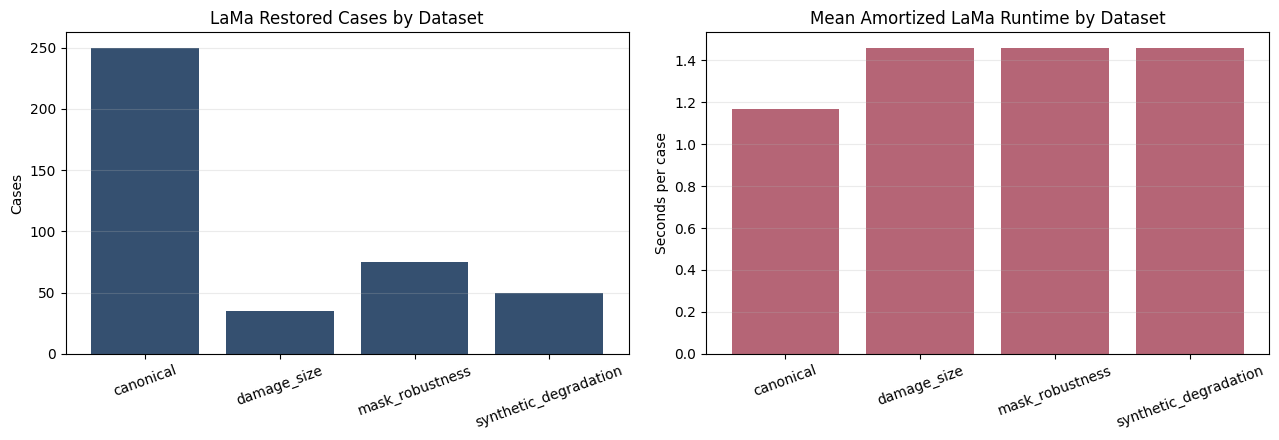

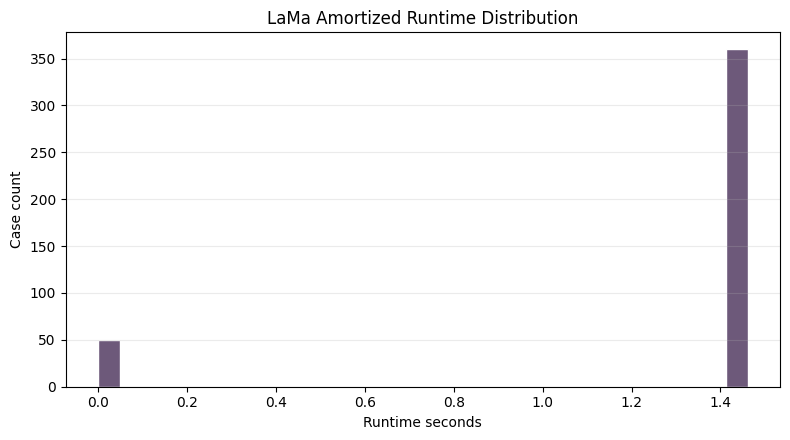

In [22]:
# Batch 3 replacement: runtime and retry visualizations

successful_runtime_df = lama_restored_metadata_df.loc[
    lama_restored_metadata_df["status"].astype(str).eq("ok")
    & lama_restored_metadata_df["runtime_seconds"].notna()
].copy()

if successful_runtime_df.empty:
    raise RuntimeError("No successful runtime rows available for plotting.")

runtime_by_dataset_df = (
    successful_runtime_df.groupby("dataset_name", dropna=False, sort=False)
    .agg(
        case_count=("restoration_case_id", "count"),
        total_runtime_seconds=("runtime_seconds", "sum"),
        mean_runtime_seconds=("runtime_seconds", "mean"),
        median_runtime_seconds=("runtime_seconds", "median"),
        max_runtime_seconds=("runtime_seconds", "max"),
        total_retries=("retry_count", "sum"),
    )
    .reset_index()
)

display(runtime_by_dataset_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(
    runtime_by_dataset_df["dataset_name"],
    runtime_by_dataset_df["case_count"],
    color="#355070",
)
axes[0].set_title("LaMa Restored Cases by Dataset")
axes[0].set_ylabel("Cases")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(
    runtime_by_dataset_df["dataset_name"],
    runtime_by_dataset_df["mean_runtime_seconds"],
    color="#b56576",
)
axes[1].set_title("Mean Amortized LaMa Runtime by Dataset")
axes[1].set_ylabel("Seconds per case")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4.5))
plt.hist(successful_runtime_df["runtime_seconds"], bins=30, color="#6d597a", edgecolor="white")
plt.title("LaMa Amortized Runtime Distribution")
plt.xlabel("Runtime seconds")
plt.ylabel("Case count")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

In [26]:
# Batch 4: reload full-run outputs if the kernel state was interrupted

import json
import re
from datetime import datetime, timezone

if "lama_restored_metadata_df" not in globals():
    if not lama_metadata_path.is_file():
        raise FileNotFoundError(f"Missing LaMa metadata CSV: {lama_metadata_path}")
    lama_restored_metadata_df = pd.read_csv(lama_metadata_path)

if "lama_restoration_audit_df" not in globals():
    if not lama_audit_path.is_file():
        raise FileNotFoundError(f"Missing LaMa audit CSV: {lama_audit_path}")
    lama_restoration_audit_df = pd.read_csv(lama_audit_path)

if "lama_restoration_summary_df" not in globals():
    lama_restoration_summary_df = summarize_lama_restoration(lama_restored_metadata_df)

if "runtime_by_dataset_df" not in globals():
    runtime_by_dataset_df = (
        lama_restored_metadata_df.loc[
            lama_restored_metadata_df["status"].astype(str).eq("ok")
            & lama_restored_metadata_df["runtime_seconds"].notna()
        ]
        .groupby("dataset_name", dropna=False, sort=False)
        .agg(
            case_count=("restoration_case_id", "count"),
            total_runtime_seconds=("runtime_seconds", "sum"),
            mean_runtime_seconds=("runtime_seconds", "mean"),
            median_runtime_seconds=("runtime_seconds", "median"),
            max_runtime_seconds=("runtime_seconds", "max"),
            total_retries=("retry_count", "sum"),
        )
        .reset_index()
    )

lama_figure_dir.mkdir(parents=True, exist_ok=True)
lama_report_dir.mkdir(parents=True, exist_ok=True)

print("Loaded LaMa rows:", len(lama_restored_metadata_df))
print("Loaded audit rows:", len(lama_restoration_audit_df))

Loaded LaMa rows: 410
Loaded audit rows: 6


In [27]:
# Batch 4: select representative cases for notebook rendering and saved panels

REPRESENTATIVE_CASES_PER_DATASET = 3
MAX_NOTEBOOK_RENDERED_PANELS = 12

successful_lama_df = lama_restored_metadata_df.loc[
    lama_restored_metadata_df["status"].astype(str).eq("ok")
].copy()

if successful_lama_df.empty:
    raise RuntimeError("No successful LaMa rows available for representative visualization.")

if "lama_mask_area_pixels" not in successful_lama_df.columns:
    successful_lama_df["lama_mask_area_pixels"] = np.nan

representative_frames = []

for dataset_name, dataset_df in successful_lama_df.groupby("dataset_name", sort=False):
    dataset_df = dataset_df.copy()

    zero_df = dataset_df.loc[
        dataset_df["lama_mask_area_pixels"].fillna(-1).astype(float).eq(0)
    ].head(1)

    nonzero_df = dataset_df.loc[
        ~dataset_df.index.isin(zero_df.index)
    ].sort_values(
        ["lama_mask_area_pixels", "painting_id", "case_id"],
        ascending=[False, True, True],
        kind="stable",
    ).head(REPRESENTATIVE_CASES_PER_DATASET)

    selected_df = pd.concat([zero_df, nonzero_df], ignore_index=False).head(
        REPRESENTATIVE_CASES_PER_DATASET
    )

    if not selected_df.empty:
        representative_frames.append(selected_df)

lama_representative_cases_df = (
    pd.concat(representative_frames, ignore_index=True)
    .drop_duplicates(subset=["restoration_case_id"], keep="first")
    .reset_index(drop=True)
)

lama_representative_cases_df["representative_rank"] = np.arange(
    1, len(lama_representative_cases_df) + 1
)

display(
    lama_representative_cases_df[
        [
            "representative_rank",
            "dataset_name",
            "case_id",
            "painting_id",
            "source_mask_semantics",
            "lama_mask_area_pixels",
            "runtime_seconds",
            "restored_path",
        ]
    ]
)

,representative_rank,dataset_name,case_id,painting_id,source_mask_semantics,lama_mask_area_pixels,runtime_seconds,restored_path
0,1,canonical,canonical__p001_zero_control,p001,binary_missing_content,0,0.000000,data/processed/restored/lama/canonical/canonic...
1,2,canonical,canonical__p031_loss_large,p031,binary_missing_content,83018,1.460938,data/processed/restored/lama/canonical/canonic...
2,3,canonical,canonical__p036_loss_large,p036,binary_missing_content,79110,1.460938,data/processed/restored/lama/canonical/canonic...
3,4,damage_size,damage_size__p001__loss_large__size_20pct,p001,binary_missing_content,101967,1.460938,data/processed/restored/lama/damage_size/damag...
4,5,damage_size,damage_size__p043__loss_large__size_20pct,p043,binary_missing_content,93869,1.460938,data/processed/restored/lama/damage_size/damag...
5,6,damage_size,damage_size__p039__loss_large__size_20pct,p039,binary_missing_content,86644,1.460938,data/processed/restored/lama/damage_size/damag...
6,7,mask_robustness,mask_robustness__p001__loss_large__variant_02,p001,binary_missing_content,63746,1.460938,data/processed/restored/lama/mask_robustness/m...
7,8,mask_robustness,mask_robustness__p001__loss_large__variant_01,p001,binary_missing_content,63739,1.460938,data/processed/restored/lama/mask_robustness/m...
8,9,mask_robustness,mask_robustness__p001__loss_large__variant_04,p001,binary_missing_content,63653,1.460938,data/processed/restored/lama/mask_robustness/m...
9,10,synthetic_degradation,synthetic_degradation__p026__water_stain__mode...,p026,grayscale_effect_intensity,0,1.460938,data/processed/restored/lama/synthetic_degrada...


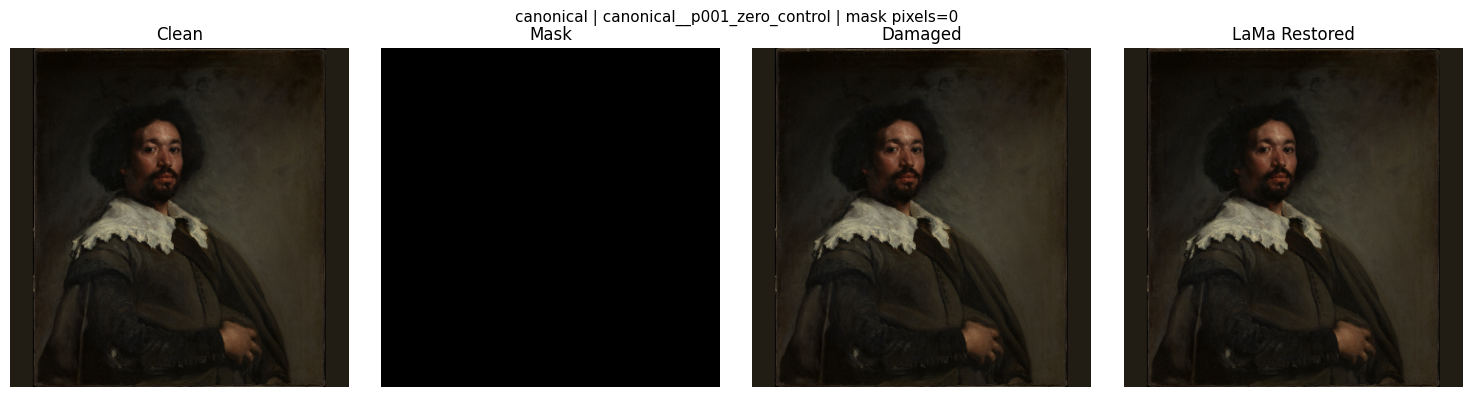

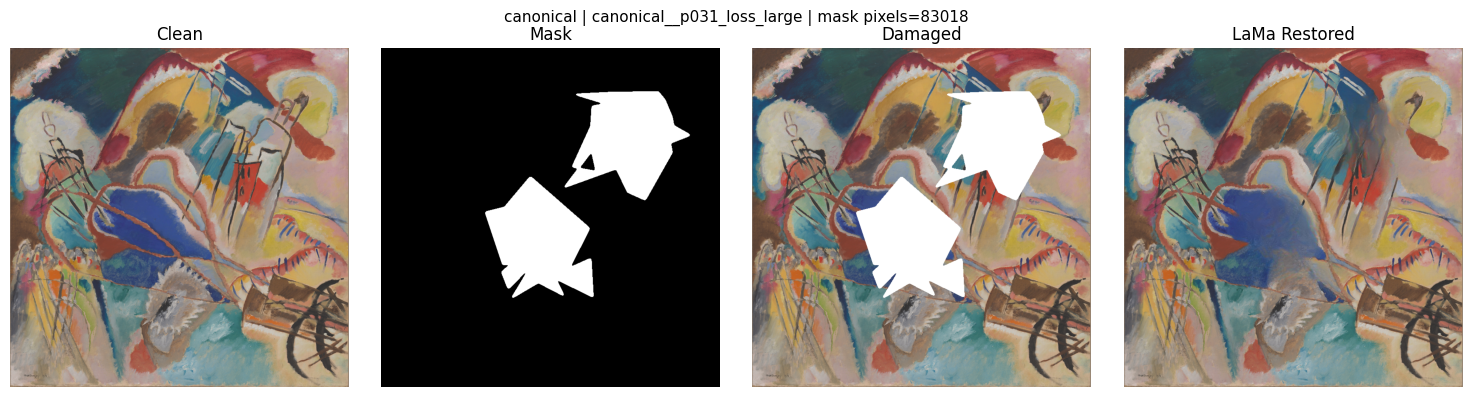

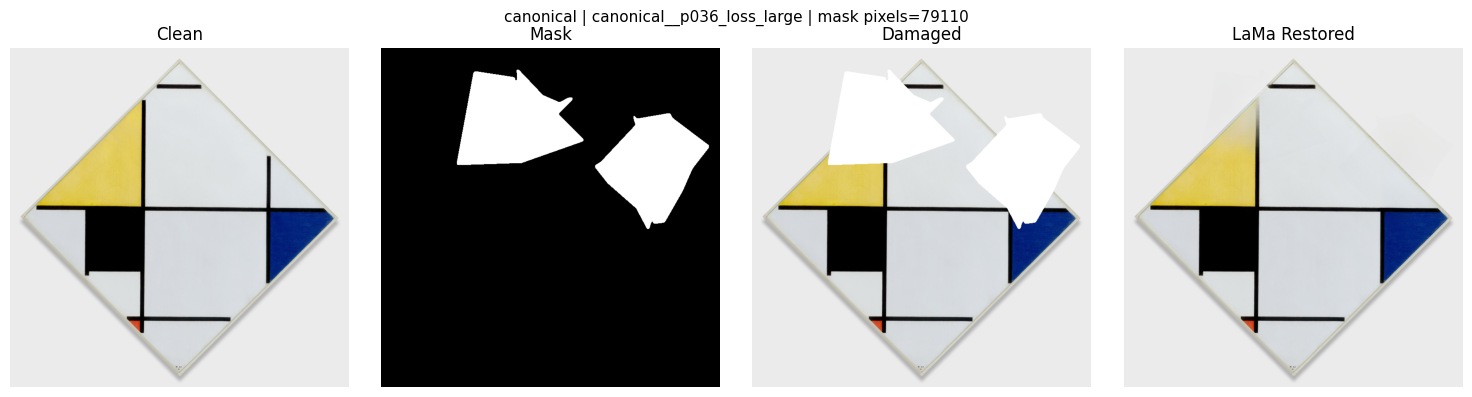

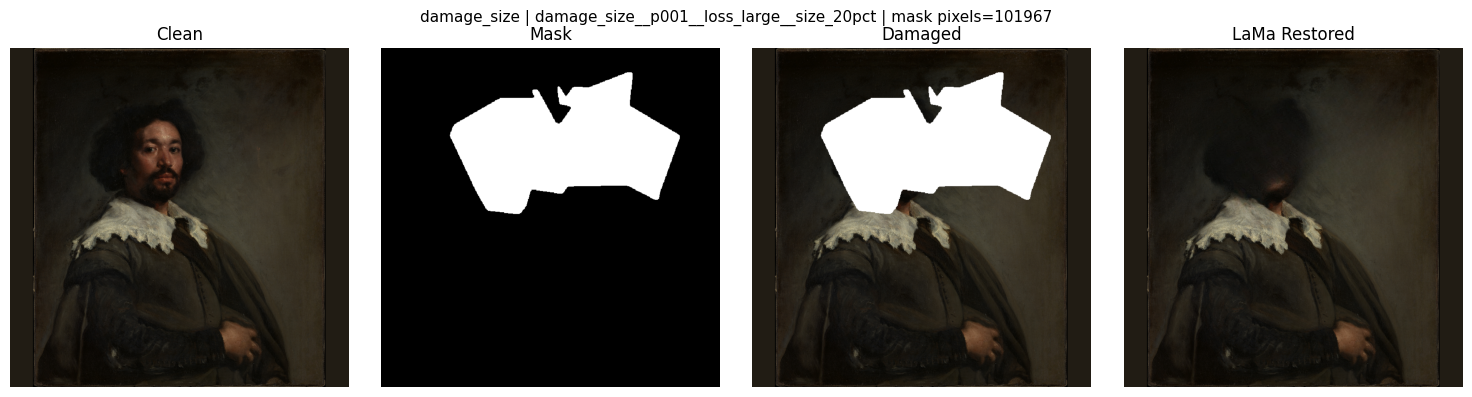

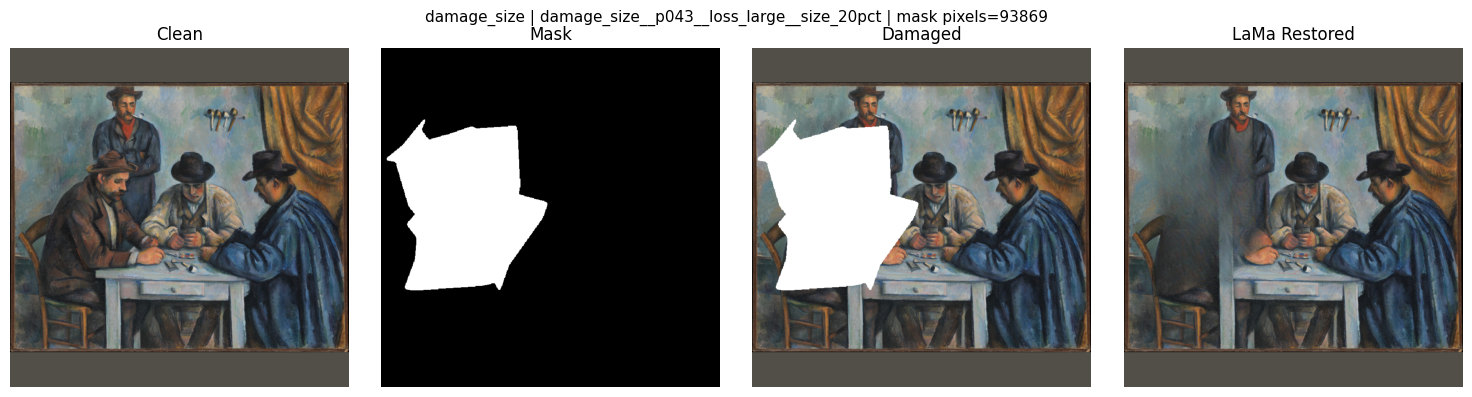

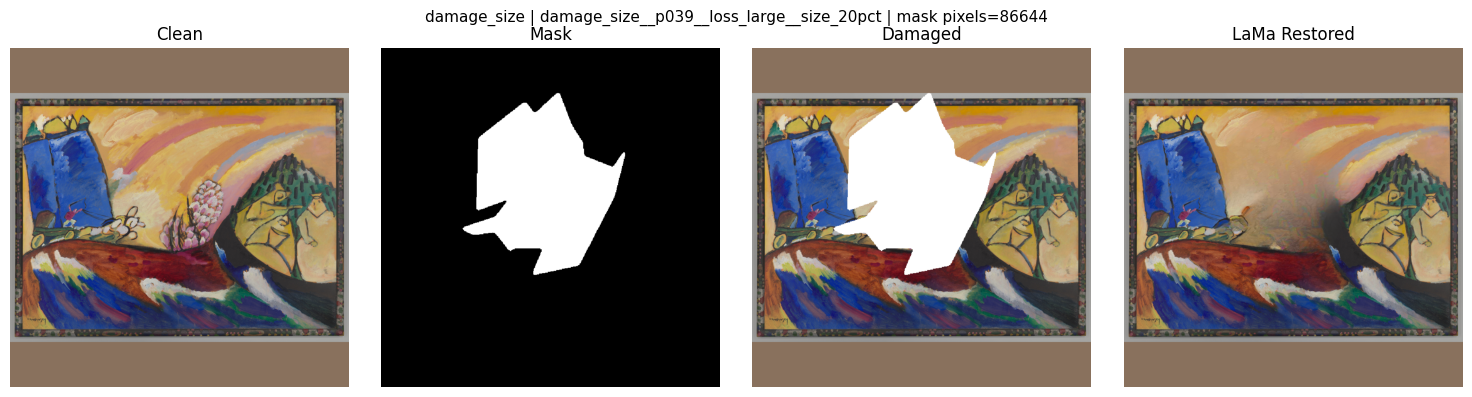

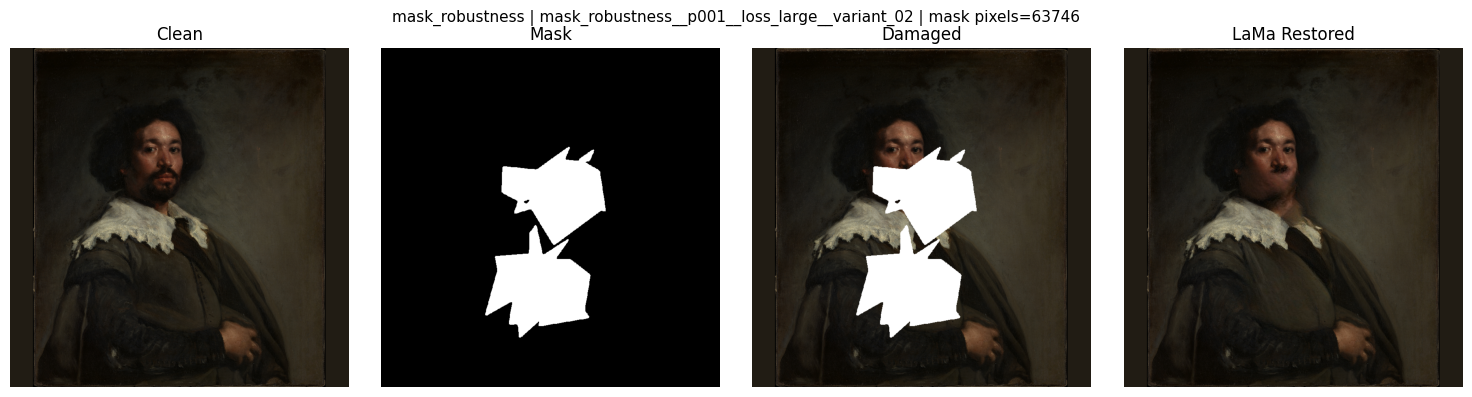

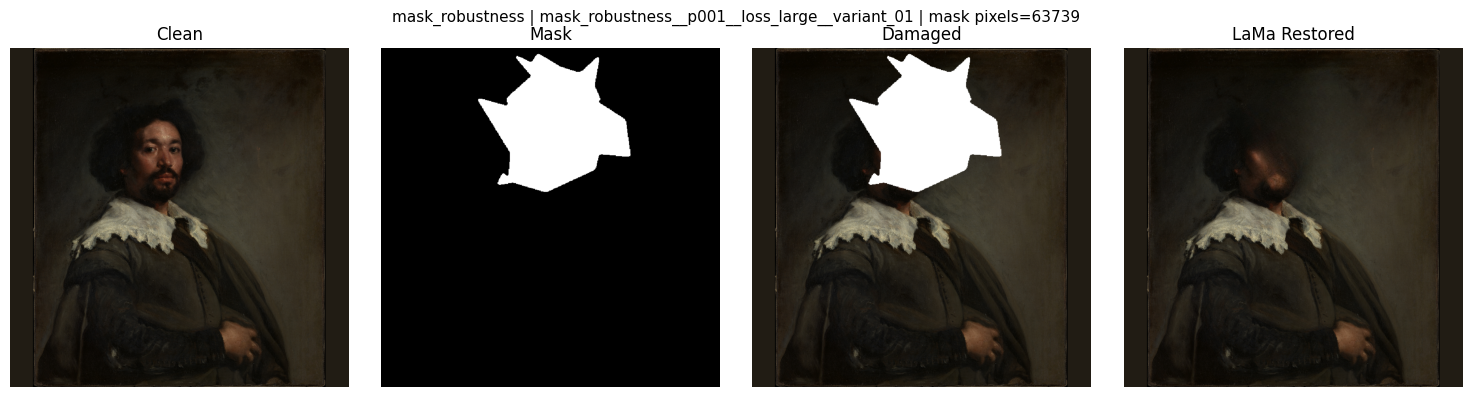

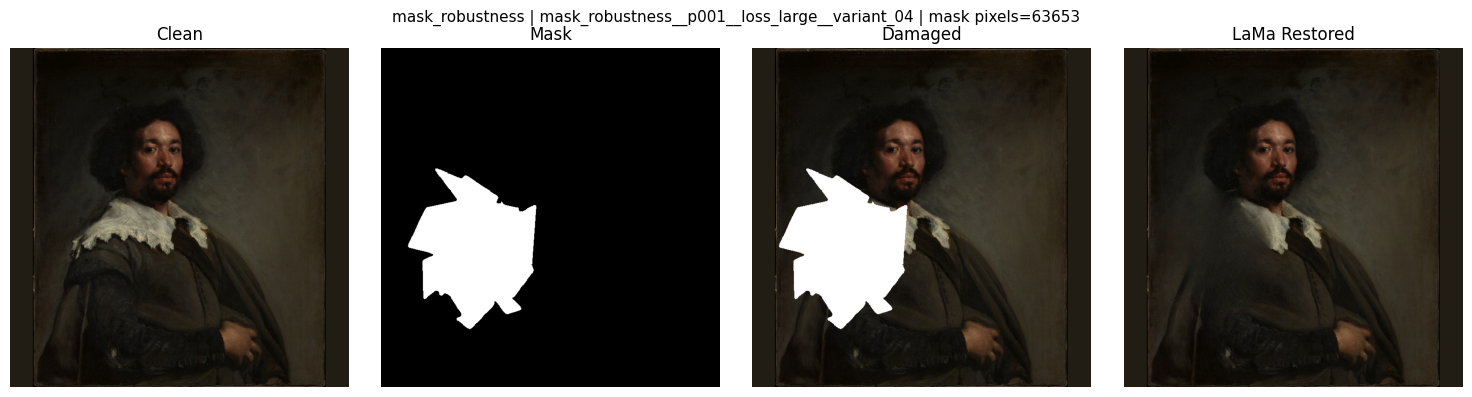

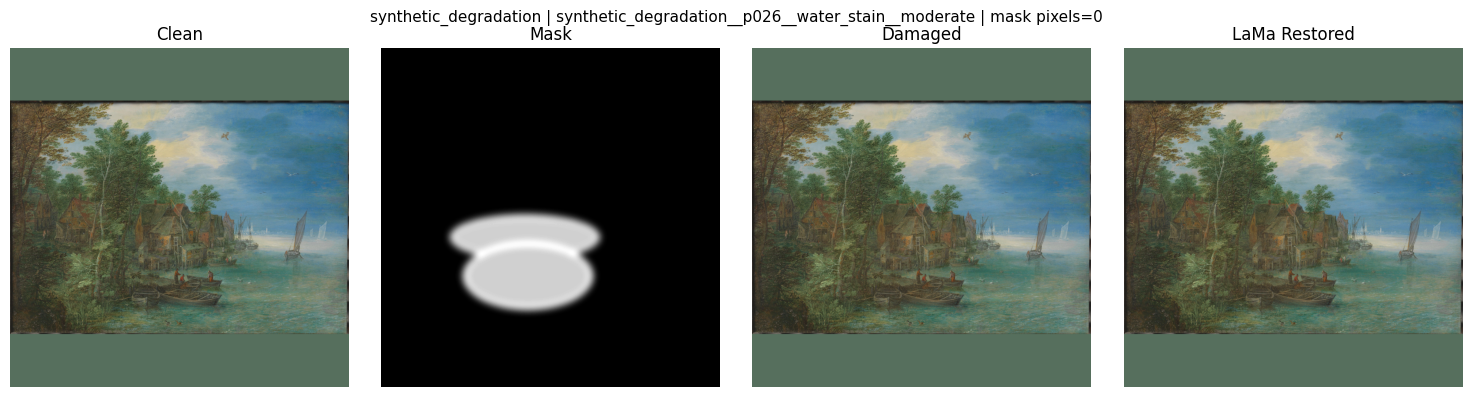

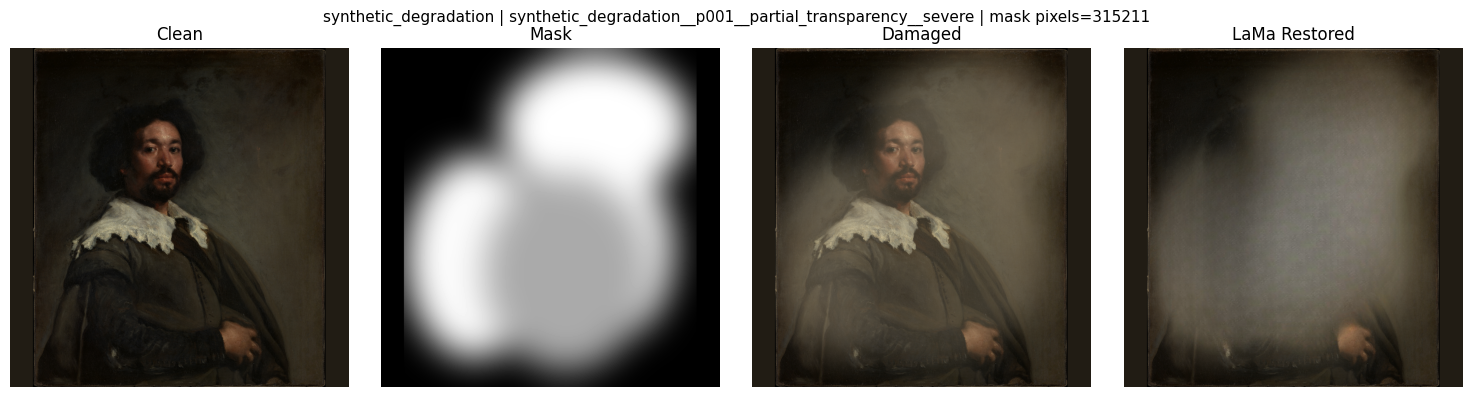

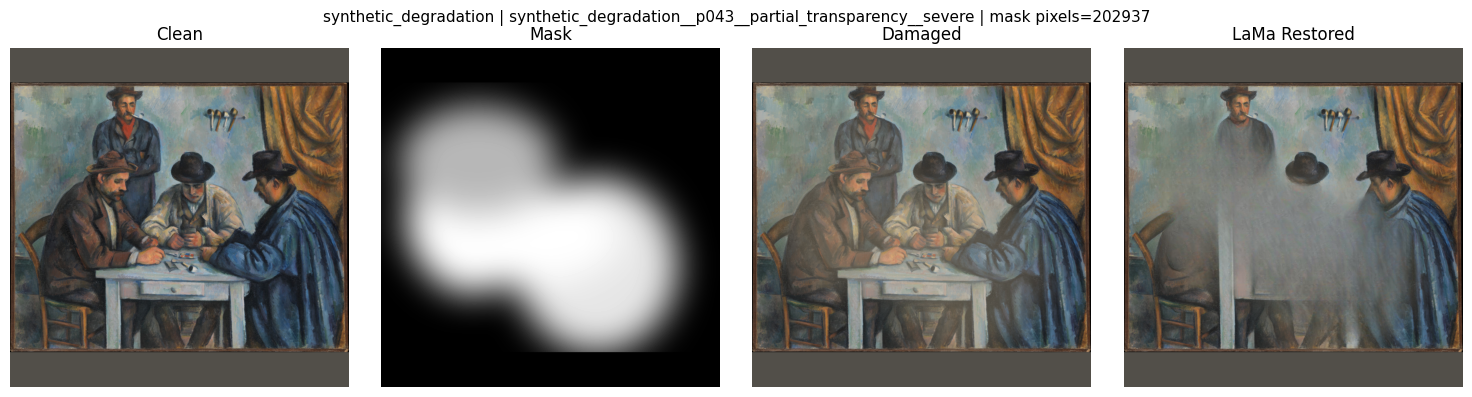

In [28]:
# Batch 4: render selected clean/mask/damaged/restored panels

def load_rgb_image_for_display(path_value: str | Path) -> np.ndarray:
    with Image.open(resolve_project_path(path_value)) as image:
        return np.asarray(image.convert("RGB"))


def load_mask_for_display(path_value: str | Path) -> np.ndarray:
    with Image.open(resolve_project_path(path_value)) as image:
        return np.asarray(image.convert("L"))


def safe_slug(value: object) -> str:
    text_value = str(value).strip().lower()
    text_value = re.sub(r"[^a-z0-9]+", "_", text_value)
    return text_value.strip("_") or "case"


def render_lama_representative_panel(row: pd.Series, output_path: Path | None = None) -> None:
    clean_image = load_rgb_image_for_display(row["clean_path"])
    mask_image = load_mask_for_display(row["mask_path"])
    damaged_image = load_rgb_image_for_display(row["damaged_path"])
    restored_image = load_rgb_image_for_display(row["restored_path"])

    fig, axes = plt.subplots(1, 4, figsize=(15, 4))

    panels = [
        ("Clean", clean_image, None),
        ("Mask", mask_image, "gray"),
        ("Damaged", damaged_image, None),
        ("LaMa Restored", restored_image, None),
    ]

    for axis, (title, image_array, cmap) in zip(axes, panels):
        axis.imshow(image_array, cmap=cmap)
        axis.set_title(title)
        axis.axis("off")

    fig.suptitle(
        (
            f"{row['dataset_name']} | {row['case_id']} | "
            f"mask pixels={row.get('lama_mask_area_pixels', 'n/a')}"
        ),
        fontsize=11,
    )
    plt.tight_layout()

    if output_path is not None:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=160, bbox_inches="tight")

    plt.show()
    plt.close(fig)


figure_manifest_rows = []

for _, row in lama_representative_cases_df.iterrows():
    panel_filename = (
        f"lama_panel_{int(row['representative_rank']):02d}_"
        f"{safe_slug(row['dataset_name'])}_"
        f"{safe_slug(row['case_id'])}.png"
    )
    panel_path = lama_figure_dir / panel_filename

    render_lama_representative_panel(row, output_path=panel_path)

    figure_manifest_rows.append(
        {
            "figure_id": f"lama_representative_panel_{int(row['representative_rank']):02d}",
            "figure_type": "representative_restoration_panel",
            "dataset_name": row["dataset_name"],
            "case_id": row["case_id"],
            "painting_id": row["painting_id"],
            "restoration_case_id": row["restoration_case_id"],
            "figure_path": project_relative_path(panel_path),
            "clean_path": row["clean_path"],
            "damaged_path": row["damaged_path"],
            "mask_path": row["mask_path"],
            "restored_path": row["restored_path"],
        }
    )

lama_figure_manifest_df = pd.DataFrame(figure_manifest_rows)

In [29]:
# Batch 4: save compact figure manifest

lama_figure_manifest_df.to_csv(lama_figure_manifest_path, index=False)

print("Saved figure manifest:")
print(project_relative_path(lama_figure_manifest_path))

display(lama_figure_manifest_df)

Saved figure manifest:
outputs/figures/lama/lama_figure_manifest.csv


,figure_id,figure_type,dataset_name,case_id,painting_id,restoration_case_id,figure_path,clean_path,damaged_path,mask_path,restored_path
0,lama_representative_panel_01,representative_restoration_panel,canonical,canonical__p001_zero_control,p001,lama__canonical__canonical__p001_zero_control,outputs/figures/lama/lama_panel_01_canonical_c...,data\processed\clean\p001_clean.png,data\processed\masked\p001_zero_control_damage...,data\processed\masks\p001_zero_control_mask.png,data/processed/restored/lama/canonical/canonic...
1,lama_representative_panel_02,representative_restoration_panel,canonical,canonical__p031_loss_large,p031,lama__canonical__canonical__p031_loss_large,outputs/figures/lama/lama_panel_02_canonical_c...,data\processed\clean\p031_clean.png,data\processed\masked\p031_loss_large_damaged.png,data\processed\masks\p031_loss_large_mask.png,data/processed/restored/lama/canonical/canonic...
2,lama_representative_panel_03,representative_restoration_panel,canonical,canonical__p036_loss_large,p036,lama__canonical__canonical__p036_loss_large,outputs/figures/lama/lama_panel_03_canonical_c...,data\processed\clean\p036_clean.png,data\processed\masked\p036_loss_large_damaged.png,data\processed\masks\p036_loss_large_mask.png,data/processed/restored/lama/canonical/canonic...
3,lama_representative_panel_04,representative_restoration_panel,damage_size,damage_size__p001__loss_large__size_20pct,p001,lama__damage_size__damage_size__p001__loss_lar...,outputs/figures/lama/lama_panel_04_damage_size...,data/processed/clean/p001_clean.png,data/processed/damaged/damage_size_sensitivity...,data/processed/masks/damage_size_sensitivity/p...,data/processed/restored/lama/damage_size/damag...
4,lama_representative_panel_05,representative_restoration_panel,damage_size,damage_size__p043__loss_large__size_20pct,p043,lama__damage_size__damage_size__p043__loss_lar...,outputs/figures/lama/lama_panel_05_damage_size...,data/processed/clean/p043_clean.png,data/processed/damaged/damage_size_sensitivity...,data/processed/masks/damage_size_sensitivity/p...,data/processed/restored/lama/damage_size/damag...
5,lama_representative_panel_06,representative_restoration_panel,damage_size,damage_size__p039__loss_large__size_20pct,p039,lama__damage_size__damage_size__p039__loss_lar...,outputs/figures/lama/lama_panel_06_damage_size...,data/processed/clean/p039_clean.png,data/processed/damaged/damage_size_sensitivity...,data/processed/masks/damage_size_sensitivity/p...,data/processed/restored/lama/damage_size/damag...
6,lama_representative_panel_07,representative_restoration_panel,mask_robustness,mask_robustness__p001__loss_large__variant_02,p001,lama__mask_robustness__mask_robustness__p001__...,outputs/figures/lama/lama_panel_07_mask_robust...,data/processed/clean/p001_clean.png,data/processed/damaged/mask_robustness/p001__l...,data/processed/masks/mask_robustness/p001__los...,data/processed/restored/lama/mask_robustness/m...
7,lama_representative_panel_08,representative_restoration_panel,mask_robustness,mask_robustness__p001__loss_large__variant_01,p001,lama__mask_robustness__mask_robustness__p001__...,outputs/figures/lama/lama_panel_08_mask_robust...,data/processed/clean/p001_clean.png,data/processed/damaged/mask_robustness/p001__l...,data/processed/masks/mask_robustness/p001__los...,data/processed/restored/lama/mask_robustness/m...
8,lama_representative_panel_09,representative_restoration_panel,mask_robustness,mask_robustness__p001__loss_large__variant_04,p001,lama__mask_robustness__mask_robustness__p001__...,outputs/figures/lama/lama_panel_09_mask_robust...,data/processed/clean/p001_clean.png,data/processed/damaged/mask_robustness/p001__l...,data/processed/masks/mask_robustness/p001__los...,data/processed/restored/lama/mask_robustness/m...
9,lama_representative_panel_10,representative_restoration_panel,synthetic_degradation,synthetic_degradation__p026__water_stain__mode...,p026,lama__synthetic_degradation__synthetic_degrada...,outputs/figures/lama/lama_panel_10_syntheti

In [31]:
# Batch 4: write machine-readable LaMa restoration manifest

def dataframe_records_for_json(dataframe: pd.DataFrame) -> list[dict]:
    clean_df = dataframe.copy()
    clean_df = clean_df.replace({np.nan: None})
    return clean_df.to_dict(orient="records")


lama_manifest_payload = {
    "notebook": "14_lama_restoration",
    "origin": "Existing Notebook 11",
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "model": {
        "restoration_method": MODEL_NAME,
        "iopaint_model_name": IOPAINT_MODEL_NAME,
        "device_requested": LAMA_DEVICE,
        "device_effective": effective_lama_device,
        "mask_binary_threshold": MASK_BINARY_THRESHOLD,
        "target_size": (
            [int(TARGET_SIZE), int(TARGET_SIZE)]
            if isinstance(TARGET_SIZE, (int, np.integer))
            else list(TARGET_SIZE)
        ),
        "max_retries": LAMA_MAX_RETRIES,
        "retry_delay_seconds": LAMA_RETRY_DELAY_SECONDS,
    },
    "runtime_environment": lama_runtime_environment,
    "inputs": {
        "canonical_metadata_path": project_relative_path(resolved_input_paths["canonical"]),
        "damage_size_metadata_path": (
            project_relative_path(resolved_input_paths["damage_size"])
            if resolved_input_paths.get("damage_size") else None
        ),
        "mask_robustness_metadata_path": (
            project_relative_path(resolved_input_paths["mask_robustness"])
            if resolved_input_paths.get("mask_robustness") else None
        ),
        "synthetic_degradation_metadata_path": (
            project_relative_path(resolved_input_paths["synthetic_degradation"])
            if resolved_input_paths.get("synthetic_degradation") else None
        ),
    },
    "outputs": {
        "restored_root_dir": project_relative_path(restored_root_dir),
        "metadata_restored_lama_csv": project_relative_path(lama_metadata_path),
        "audit_csv": project_relative_path(lama_audit_path),
        "figure_manifest_csv": project_relative_path(lama_figure_manifest_path),
        "json_manifest": project_relative_path(lama_manifest_path),
        "markdown_report": project_relative_path(lama_report_path),
    },
    "summary": {
        "expected_cases": int(len(lama_restoration_input_manifest_df)),
        "metadata_rows": int(len(lama_restored_metadata_df)),
        "successful_cases": int(lama_restored_metadata_df["status"].astype(str).eq("ok").sum()),
        "failed_cases": int(lama_restored_metadata_df["status"].astype(str).ne("ok").sum()),
        "total_runtime_seconds": float(
            lama_restored_metadata_df["runtime_seconds"].fillna(0).sum()
        ),
        "total_retries": int(lama_restored_metadata_df["retry_count"].fillna(0).sum()),
    },
    "dataset_summary": dataframe_records_for_json(lama_restoration_summary_df),
    "runtime_summary": dataframe_records_for_json(runtime_by_dataset_df),
    "audit_summary": dataframe_records_for_json(lama_restoration_audit_df),
    "figure_manifest": dataframe_records_for_json(lama_figure_manifest_df),
    "methodological_scope": {
        "processed_case_families": sorted(
            lama_restored_metadata_df["dataset_name"].astype(str).unique().tolist()
        ),
        "synthetic_degradation_policy": (
            "Only synthetic degradation cases with explicit image-like degradation "
            "and a meaningful inpainting/effect mask are eligible for LaMa restoration."
        ),
        "excluded_synthetic_degradation_types": (
            synthetic_policy_df.loc[
                ~synthetic_policy_df["lama_eligible"].astype(bool),
                "degradation_type",
            ].astype(str).tolist()
            if "synthetic_policy_df" in globals()
            else []
        ),
    },
}

lama_manifest_path.write_text(
    json.dumps(lama_manifest_payload, indent=2, sort_keys=False),
    encoding="utf-8",
)

print("Saved JSON manifest:")
print(project_relative_path(lama_manifest_path))

Saved JSON manifest:
outputs/reports/lama_restoration_manifest.json


In [32]:
# Batch 4: write human-readable LaMa restoration report

def markdown_table(dataframe: pd.DataFrame) -> str:
    if dataframe.empty:
        return "_No rows._"
    return dataframe.to_markdown(index=False)


failed_cases_count = int(lama_restored_metadata_df["status"].astype(str).ne("ok").sum())
successful_cases_count = int(lama_restored_metadata_df["status"].astype(str).eq("ok").sum())
total_runtime_seconds = float(lama_restored_metadata_df["runtime_seconds"].fillna(0).sum())
total_runtime_minutes = total_runtime_seconds / 60.0

report_text = f"""# Notebook 14 - LaMa Restoration Report

## Scope

This notebook applies LaMa restoration to the eligible restoration cases prepared upstream.

Processed case families:

{chr(10).join(f"- `{name}`" for name in sorted(lama_restored_metadata_df["dataset_name"].astype(str).unique()))}

## Inputs

- Canonical metadata: `{project_relative_path(resolved_input_paths["canonical"])}`
- Damage-size metadata: `{project_relative_path(resolved_input_paths["damage_size"]) if resolved_input_paths.get("damage_size") else "not available"}`
- Mask-robustness metadata: `{project_relative_path(resolved_input_paths["mask_robustness"]) if resolved_input_paths.get("mask_robustness") else "not available"}`
- Synthetic-degradation metadata: `{project_relative_path(resolved_input_paths["synthetic_degradation"]) if resolved_input_paths.get("synthetic_degradation") else "not available"}`

## Outputs

- Main LaMa restoration metadata: `{project_relative_path(lama_metadata_path)}`
- Consolidated audit table: `{project_relative_path(lama_audit_path)}`
- Figure manifest: `{project_relative_path(lama_figure_manifest_path)}`
- JSON manifest: `{project_relative_path(lama_manifest_path)}`
- Restored image root: `{project_relative_path(restored_root_dir)}`

## Execution Summary

- Expected eligible cases: `{len(lama_restoration_input_manifest_df)}`
- Restored metadata rows: `{len(lama_restored_metadata_df)}`
- Successful cases: `{successful_cases_count}`
- Failed cases: `{failed_cases_count}`
- Total runtime seconds: `{total_runtime_seconds:.2f}`
- Total runtime minutes: `{total_runtime_minutes:.2f}`
- Total retries: `{int(lama_restored_metadata_df["retry_count"].fillna(0).sum())}`
- Requested device: `{LAMA_DEVICE}`
- Effective device: `{effective_lama_device}`
- IOPaint model: `{IOPAINT_MODEL_NAME}`

## Dataset Summary

{markdown_table(lama_restoration_summary_df)}

## Runtime Summary

{markdown_table(runtime_by_dataset_df)}

## Audit Summary

{markdown_table(lama_restoration_audit_df)}

## Synthetic-Degradation Eligibility

LaMa is used only where the synthetic-degradation case can be interpreted as an inpainting-style restoration problem with a concrete mask. Cases outside this policy are excluded from Notebook 14 rather than treated as LaMa failures.

## Method Notes

- Case identifiers are standardized as `lama__<dataset_name>__<case_id>`.
- Zero-control rows are copied without model inference and explicitly marked in the metadata.
- Runtime, retry count, attempt count, model name, device, restored path, and validation outcomes are recorded.
- This notebook intentionally saves a small number of tabular outputs: the main metadata CSV, one audit CSV, and one figure manifest CSV.
- All restored image files are saved under the LaMa restored root.
"""

lama_report_path.write_text(report_text, encoding="utf-8")

print("Saved Markdown report:")
print(project_relative_path(lama_report_path))

Saved Markdown report:
outputs/reports/lama_restoration_report.md


In [33]:
# Batch 4: final output gate for Notebook 14

required_output_paths = [
    lama_metadata_path,
    lama_audit_path,
    lama_figure_manifest_path,
    lama_manifest_path,
    lama_report_path,
]

required_output_checks = []

for output_path in required_output_paths:
    required_output_checks.append(
        {
            "check": f"required_output_exists::{output_path.name}",
            "path": project_relative_path(output_path),
            "observed": output_path.is_file() and output_path.stat().st_size > 0,
            "expected": True,
            "passed": output_path.is_file() and output_path.stat().st_size > 0,
        }
    )

expected_restored_paths = lama_restored_metadata_df.loc[
    lama_restored_metadata_df["status"].astype(str).eq("ok"),
    "restored_path",
].map(resolve_project_path)

missing_restored_paths = [
    path for path in expected_restored_paths
    if not path.is_file() or path.stat().st_size == 0
]

required_output_checks.append(
    {
        "check": "all_successful_rows_have_restored_files",
        "path": project_relative_path(restored_root_dir),
        "observed": len(missing_restored_paths),
        "expected": 0,
        "passed": len(missing_restored_paths) == 0,
    }
)

notebook_owned_csv_paths = sorted(
    [
        path
        for path in set(lama_output_dir.rglob("*.csv")) | set(lama_figure_dir.rglob("*.csv"))
        if path.is_file()
    ]
)

allowed_csv_paths = {
    lama_audit_path.resolve(),
    lama_figure_manifest_path.resolve(),
}

unexpected_csv_paths = [
    path for path in notebook_owned_csv_paths
    if path.resolve() not in allowed_csv_paths
]

required_output_checks.append(
    {
        "check": "no_unexpected_notebook_owned_csv_sprawl",
        "path": project_relative_path(lama_output_dir),
        "observed": [project_relative_path(path) for path in unexpected_csv_paths],
        "expected": [],
        "passed": len(unexpected_csv_paths) == 0,
    }
)

final_output_gate_df = pd.DataFrame(required_output_checks)

display(final_output_gate_df)

failed_final_output_gate_df = final_output_gate_df.loc[
    ~final_output_gate_df["passed"].astype(bool)
].copy()

if not failed_final_output_gate_df.empty:
    raise RuntimeError(
        "Notebook 14 final output gate failed:\n"
        + failed_final_output_gate_df.to_string(index=False)
    )

display(Markdown("**Notebook 14 final output gate passed.**"))

,check,path,observed,expected,passed
0,required_output_exists::metadata_restored_lama...,data/processed/metadata/metadata_restored_lama...,True,True,True
1,required_output_exists::lama_restoration_audit...,outputs/14_lama_restoration/lama_restoration_a...,True,True,True
2,required_output_exists::lama_figure_manifest.csv,outputs/figures/lama/lama_figure_manifest.csv,True,True,True
3,required_output_exists::lama_restoration_manif...,outputs/reports/lama_restoration_manifest.json,True,True,True
4,required_output_exists::lama_restoration_repor...,outputs/reports/lama_restoration_report.md,True,True,True
5,all_successful_rows_have_restored_files,data/processed/restored/lama,0,0,True
6,no_unexpected_notebook_owned_csv_sprawl,outputs/14_lama_restoration,[],[],True


**Notebook 14 final output gate passed.**

In [34]:
# Batch 4: completion summary

display(
    Markdown(
        f"""
## Notebook 14 Complete

LaMa restoration is complete and ready for downstream metric notebooks.

- Eligible input cases: `{len(lama_restoration_input_manifest_df)}`
- Restored metadata rows: `{len(lama_restored_metadata_df)}`
- Successful restorations: `{successful_cases_count}`
- Failed restorations: `{failed_cases_count}`
- Main restoration manifest: `{project_relative_path(lama_metadata_path)}`
- Consolidated audit CSV: `{project_relative_path(lama_audit_path)}`
- Figure manifest CSV: `{project_relative_path(lama_figure_manifest_path)}`
- JSON experiment manifest: `{project_relative_path(lama_manifest_path)}`
- Markdown report: `{project_relative_path(lama_report_path)}`
- Restored images: `{project_relative_path(restored_root_dir)}`

Notebook 15 can now consume `metadata_restored_lama.csv` using the same standardized case-family structure as the OpenCV branch.
"""
    )
)


## Notebook 14 Complete

LaMa restoration is complete and ready for downstream metric notebooks.

- Eligible input cases: `410`
- Restored metadata rows: `410`
- Successful restorations: `410`
- Failed restorations: `0`
- Main restoration manifest: `data/processed/metadata/metadata_restored_lama.csv`
- Consolidated audit CSV: `outputs/14_lama_restoration/lama_restoration_audit.csv`
- Figure manifest CSV: `outputs/figures/lama/lama_figure_manifest.csv`
- JSON experiment manifest: `outputs/reports/lama_restoration_manifest.json`
- Markdown report: `outputs/reports/lama_restoration_report.md`
- Restored images: `data/processed/restored/lama`

Notebook 15 can now consume `metadata_restored_lama.csv` using the same standardized case-family structure as the OpenCV branch.
